# 40.05 Методика оценки чувствительности передаточного импеданса к свойствам тканевых компартментов

## Вычислительный эксперимент с параметризованными электродами на модельных руках

**Назначение работы.** Настоящий ноутбук документирует предварительный этап разработки метода: проверку физических предположений, выявление зависимостей передаточного импеданса от электрических свойств тканей и настройку программной реализации расчёта чувствительности. Монтажи на модельных руках образуют ограниченный тестовый набор, на котором проверяются определения, численные процедуры и способы сравнения. Последующая исследовательская задача состоит в применении этого подхода к существенно различающимся электродным сборкам.

**Объект исследования** — индивидуальная геометрия туловища добровольца Nix, построенная на основе КТ и ручной сегментации, дополненная искусственными цилиндрическими участками рук. **Предмет исследования** — зависимость четырёхэлектродного передаточного импеданса и его производных от проводимостей трёх эффективных компартментов при фиксированных геометрии и контактах.

**Уровень доказательности.** Представлены результаты математической модели и численная верификация её дискретной реализации методом конечных элементов (МКЭ, FEM). Экспериментальные физиологические сигналы в этот расчёт не входят. Физическая адекватность полученных коэффициентов для реального прибора, устойчивость обратной задачи на измерениях и возможность оценки функций сердца остаются открытыми вопросами.

В основной матрице рассмотрены 16 монтажей и 27 сочетаний проводимостей, то есть 432 расчётных состояния. Для каждого состояния сохранены передаточный импеданс, размерные и относительные чувствительности, а также показатели численного контроля. Дополнительные решения использованы для проверки производных. Настоящая подробная редакция анализирует сохранённую матрицу и не подменяет её повторным расчётом с изменёнными исходниками.

## 1. Исследовательская задача и проверяемые предположения

Чувствительность электродной сборки характеризует изменение измеряемой величины при заданном возмущении параметров модели. Для обоснованного сравнения сборок необходимо одновременно определить изменяемый параметр, масштаб его возмущения, исходное состояние тканей, измерительный канал и параметры, сохраняемые постоянными. Сравнение одних базовых импедансов этих сведений не заменяет.

В данной работе рассматриваются три разных вопроса. Первый — насколько отклик каждой сборки зависит от проводимости выбранного компартмента. Второй — насколько изменение формы и положения электродов меняет этот отклик при одинаковых тканевых параметрах. Третий — содержат ли показания нескольких сборок достаточно различающуюся информацию для раздельной оценки нескольких проводимостей. Последний вопрос относится к обратной задаче и требует более строгих условий, чем вычисление отдельных производных.

| Проверяемое предположение | Способ проверки в данном эксперименте | Допустимый уровень вывода |
|---|---|---|
| Форма контактной поверхности существенно меняет сердечную чувствительность | Попарное сравнение монтажей при одинаковых проводимостях и расстояниях | Сравнение коэффициентов фиксированной модели |
| Удаление внутренней пары от туловища усиливает сердечный отклик | Сравнение расстояний 20 и 40 мм при неизменном разносе I–V | Геометрическая зависимость в пределах двух заданных положений |
| Наружные плоскости дают преимущество перед кольцевыми контактами | Сопоставление 108 совпадающих наборов тканевых и геометрических параметров | Проверка двух конкретных дискретных контактных моделей |
| Преимущественная чувствительность к одной ткани сохраняется при изменении остальных | Полная комбинационная матрица проводимостей | Устойчивость зависимости на выбранной сетке сценариев |
| Несколько похожих монтажей позволяют разделить три проводимости | Анализ матрицы производных и её сингулярных значений | Локальная обусловленность при заданном масштабировании |
| Программная реализация корректно вычисляет производные | Сопоставление с конечными разностями, проверка взаимности и независимого решателя | Численная верификация дискретной задачи |

Эта таблица систематизирует исследовательские вопросы при подготовке отчёта. Она не является протоколом предварительно зарегистрированного статистического испытания: случайная выборка, нулевая статистическая гипотеза и уровень значимости здесь не задавались. Отрицательный результат отдельного сравнения сохраняет методическую ценность, если позволяет установить границы информативности монтажа или обнаружить зависимость результата от выбранного определения чувствительности.

## 2. Происхождение входов и связь с экспериментальной анатомией

КТ добровольца была выполнена на вдохе; итоговая сегментация основных анатомических областей выполнена автором вручную в Inobitec. Поверхности сегментированных областей использованы при подготовке геометрии и назначении тканевых классов тетраэдрам. Связь с индивидуальной КТ обеспечивает анатомическую основу модели, однако добавленные цилиндры рук и электрические параметры содержат самостоятельные допущения.

| Вход или решение | Происхождение | Роль в расчёте и ограничение |
|---|---|---|
| КТ туловища | Индивидуальная визуализация на вдохе | Геометрический референс одного состояния дыхания |
| Поверхности сердца, лёгких и костей | Ручная сегментация с последующей подготовкой STL | Основа классификации элементов; погрешность сегментации не оценена количественно |
| Расчётная сетка | Производный результат геометрической подготовки и тетраэдризации | Дискретизация фиксированной геометрии; пригодность подтверждена техническими проверками |
| Цилиндрические участки рук | Конструктивное допущение модели | Воспроизводимая поверхность для параметрического изменения электродов |
| Форма и координаты контактов | Заданные расчётные сценарии | Не являются измерением фактической наклейки электродов |
| Тканевые ориентиры проводимости | Частотная модель IT’IS/Gabriel при 50 кГц | Используются как внешние ориентиры, без индивидуальной идентификации |
| Опорные параметры фона и лёгких | Параметры предыдущей конфигурации проекта | Сохраняют сопоставимость с исходным расчётом; независимая оценка их погрешности отсутствует |
| Единая эффективная сердечная область | Допущение, принятое автором | Компенсирует отсутствие отдельной маски крови; состав смеси не установлен |
| Контактный импеданс | Фиксированный параметр прежней модели | Не является результатом измерения контакта в данной серии |

Материалы экспериментов с РЕО32, реокардиомониторами МГТУ и РНЦХ в эту матрицу не включены. Поэтому сопоставимость измерительных шкал разных приборов и восстановление дыхательных интервалов не используются как основания настоящих выводов. Расчёт предназначен для подготовки физического звена методики, которое в дальнейшем потребуется сопоставить с конкретным протоколом измерений.

Следующая ячейка проверяет сохранённые результаты до их интерпретации. Проверки охватывают полноту матрицы, контрольные суммы, использованную версию исходников, геометрию контактов и численные критерии. Сам факт наличия таблицы с результатами не принимается за подтверждение корректности её происхождения.

In [1]:
from pathlib import Path
import json, hashlib, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'MATLAB_TRKG4_real_subjects').is_dir())
MODEL=ROOT/'MATLAB_TRKG4_real_subjects'
OUT=MODEL/'output'/'exploratory'/'arm_sigma_20260908'
identity=json.loads((OUT/'identity.json').read_text(encoding='utf-8-sig'))
study=identity['study']
python_identity=json.loads((OUT/'python_identity.json').read_text(encoding='utf-8'))
assert python_identity['matlab_identity_sha256']==hashlib.sha256((OUT/'identity.json').read_bytes()).hexdigest()
completion=json.loads((OUT/'completion.json').read_text(encoding='utf-8'))
assert completion['status']=='matrix_completed_numerical_checks_passed'
manifest=json.loads((OUT/'result_integrity.json').read_text(encoding='utf-8'))
for name,digest in manifest['files'].items():
    assert hashlib.sha256((OUT/name).read_bytes()).hexdigest()==digest, f'Изменён файл результата: {name}'
assert study['status']=='exploratory_hypothesis_not_validated'
changed_working_sources=[]
with zipfile.ZipFile(OUT/'source_used_matrix.zip') as used_sources:
    assert python_identity['source_sha256']==hashlib.sha256(used_sources.read('tools/solve_arm_conductivity_matrix.py')).hexdigest()
    for item in identity['sources']:
        assert hashlib.sha256(used_sources.read(item['path'])).hexdigest()==item['sha256'], f"Повреждён архив исходников: {item['path']}"
        live=MODEL/item['path']
        if not live.exists() or hashlib.sha256(live.read_bytes()).hexdigest()!=item['sha256']:
            changed_working_sources.append(item['path'])
acceptance=json.loads((MODEL/'output'/'accepted_arm_parameter_mesh_acceptance.json').read_text(encoding='utf-8'))
assert acceptance['status']=='accepted_for_parameterized_arm_electrode_method_development'
assert all(acceptance['checks'].values())
with (MODEL/'output'/'accepted_arm_parameter_mesh.msh').open('rb') as f:
    mesh_hash=hashlib.file_digest(f,'sha256').hexdigest()
assert mesh_hash==identity['mesh_sha256']==acceptance['accepted_mesh_sha256']
files=sorted(OUT.glob('in*_results.csv'))
df=pd.concat([pd.read_csv(p) for p in files],ignore_index=True)
assert len(df)==432 and df['montage'].nunique()==16
assert not df.duplicated(['montage','case_index']).any()
assert (df.groupby('montage')['case_index'].nunique()==27).all()
assert set(df.electrode_kind)==set(study['montage_kinds'])
assert np.isfinite(df.select_dtypes('number').drop(columns=['solver_warning','solver_warning_message'],errors='ignore')).all().all()
assert np.allclose(df[['sigma_soft','sigma_heart','sigma_lung']].to_numpy(),np.asarray(study['parameter_matrix'])[df.case_index.to_numpy(dtype=int)-1],rtol=1e-12,atol=1e-14)
assert (df.reciprocity_relative_error<1e-8).all()
assert (df.relative_residual<1e-7).all()
assert (df.matrix_relative_error<1e-12).all()
patch_tables=[]
for p in sorted(OUT.glob('in*_patches.csv')):
    tab=pd.read_csv(p);tab['montage']=p.name.removesuffix('_patches.csv');patch_tables.append(tab)
patches=pd.concat(patch_tables,ignore_index=True)
assert len(patches)==64 and (patches.groupby('montage').size()==4).all()
assert (patches.pass_clearance==1).all()
assert (patches.face_count>0).all() and (patches.node_count>0).all()
is_plane=patches.contact_geometry=='internal_plane'
assert is_plane.sum()==8
assert set(patches.loc[is_plane,'label'])=={'I_plus','I_minus'}
mixed=patches.electrode_kind=='outer_planes_inner_rings'
assert (patches.loc[mixed&~is_plane,'contact_geometry']=='surface_cuff').all()
assert (patches.loc[mixed&~is_plane,'axial_width_mm']==5).all()
assert patches.loc[~is_plane,'area_ratio'].between(.95,1.05).all()
assert patches.loc[is_plane,'projected_cross_section_area_ratio'].between(.95,1.05).all()
assert ((patches.loc[is_plane,'patch_x_max_mm']-patches.loc[is_plane,'patch_x_min_mm'])<=3).all()
assert ((patches.patch_x_centroid_mm-patches.x_mm).abs()<=.5).all()
fd=pd.concat([pd.read_csv(p).assign(montage=p.name.removesuffix('_derivative_qc.csv')) for p in OUT.glob('*_derivative_qc.csv')],ignore_index=True)
assert len(fd)==24 and fd.montage.nunique()==4
assert (fd.relative_error<.002).all()
labels={'point_disc_5mm':'Диски диаметром 5 мм','circumferential_ring':'Кольца 5 мм',
        'wide_cuff_equivalent_area':'Манжеты 15 мм','outer_planes_inner_rings':'Наружные плоскости + внутренние кольца'}
short={'point_disc_5mm':'Диски','circumferential_ring':'Кольца',
       'wide_cuff_equivalent_area':'Широкие манжеты','outer_planes_inner_rings':'Плоскости + кольца'}
tissues=['soft','heart','lung']
tissue_labels=['Мягкотканный фон','Сердечная область','Лёгкие']
baseline=np.asarray(study['baseline'])
base=df[np.isclose(df[['sigma_soft','sigma_heart','sigma_lung']],baseline).all(axis=1)].sort_values('montage_index').copy()
assert len(base)==16
ANALYSIS=OUT/'notebook_analysis'
ANALYSIS.mkdir(exist_ok=True)
old=pd.read_csv(OUT/'historical_40_02_summary.csv')
old_identity=json.loads((OUT/'historical_reference_identity.json').read_text(encoding='utf-8'))
assert hashlib.sha256((OUT/'historical_40_02_summary.csv').read_bytes()).hexdigest()==old_identity['sha256']
regression=base.merge(old,left_on='montage',right_on='scenario_id',suffixes=('','_old'))
assert len(regression)==12
regression['relative_difference']=(regression.Z_direct_ohm-regression.Z_direct_real_ohm).abs()/regression.Z_direct_real_ohm.abs()
assert (regression.relative_difference<1e-8).all()
base['label']=[f"{short[k]} · {i}/{o}" for k,i,o in zip(base.electrode_kind,base.inner_mm,base.outer_mm)]
pd.set_option('display.max_rows',40)
pd.set_option('display.max_colwidth',None)
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
display(Markdown(f'Контроль входных результатов завершён: **{len(df)} расчётных состояния, {len(base)} монтажей и {len(patches)} контактные поверхности**. Проверены целостность сохранённых данных, полнота сочетаний параметров и соответствие использованной версии расчётного кода.'))

Контроль входных результатов завершён: **432 расчётных состояния, 16 монтажей и 64 контактные поверхности**. Проверены целостность сохранённых данных, полнота сочетаний параметров и соответствие использованной версии расчётного кода.

## 3. Компартментная структура модели

Под компартментом понимается область расчётного объёма, которой назначена одна скалярная проводимость. Такая параметризация описывает эффективные электрические свойства области при заданной частоте. Она не требует анатомической однородности всех тканей внутри этой области и не задаёт способ физического смешения её составляющих.

В модели выделены четыре электрических класса: мягкотканный фон, лёгкие, сердечная область и кости. Мягкотканный фон заполняет элементы, не отнесённые к отдельным органным маскам, и включает искусственные участки рук. Кожа, жировая ткань и мышцы в нём отдельно не параметризованы. Левое и правое лёгкие изменяются совместно одним параметром. Костный класс имеет постоянную проводимость.

Сердечная область соответствует всей имеющейся маске сердца. По решению автора её проводимость рассматривается как эффективный параметр смеси крови и миокарда. В расчёте отсутствуют отдельные неизвестные проводимости крови и миокарда, доли их объёмов, форма камер и изменение кровенаполнения. Арифметическая середина двух тканевых ориентиров задаёт промежуточный сценарий проводимости; вывод о равных объёмных долях крови и миокарда из неё не следует.

При назначении классов определяется принадлежность центроида каждого тетраэдра замкнутой поверхности. В использованной конфигурации после фонового заполнения последовательно применяются маски лёгких, сердца и костей; последующее назначение имеет приоритет при пересечении масок. Тканевый класс присваивается элементу целиком. Поэтому положение границ в электрической модели зависит от разрешения сетки и правила классификации, а объёмы назначенных элементов могут отличаться от объёмов исходных поверхностей.

Для дополнительной диагностики мягкотканный класс разделён плоскостями соединения туловища с цилиндрами рук на две непересекающиеся части. Их производные рассчитываются отдельно, но в основной матрице обеим частям назначена одна и та же проводимость. Это пространственное разложение фоновой чувствительности, а не два дополнительных независимо варьируемых параметра.

## 4. Геометрия электродов и исправление исходной постановки

Используется четырёхэлектродное измерение: наружная пара I+/I− вводит и отводит ток, внутренняя пара V+/V− определяет разность потенциалов. На каждой стороне расстояние до внутреннего электрода отсчитывается от модельной плоскости соединения туловища с рукой; наружный электрод расположен дальше на заданное расстояние I–V. Обозначение «20/80 мм» означает 20 мм от соединения до V и ещё 80 мм от V до I, то есть 100 мм от соединения до токового электрода.

Рассмотрены внутренние расстояния 20 и 40 мм и разносы I–V 80 и 100 мм. Таким образом, переход 20→40 мм при постоянном разносе одновременно смещает обе пары электродов. Он не является отдельным экспериментом по перемещению только измерительной пары. Радиус модельных цилиндров равен 30 мм, их заданная длина — 168 мм.

| Контактная конфигурация | Наружные I+/I− | Внутренние V+/V− | Номинальная площадь одного контакта |
|---|---|---|---|
| Малые диски | Поверхностные диски диаметром 5 мм | Такие же диски | Около 19,63 мм² |
| Узкие кольцевые манжеты | Манжеты шириной 5 мм вокруг цилиндра | Такие же манжеты | Около 942,48 мм² |
| Широкие кольцевые манжеты | Манжеты шириной 15 мм | Такие же манжеты | Около 2827,43 мм² |
| Смешанный монтаж | Поперечные поверхности сечений цилиндров | Поверхностные манжеты шириной 5 мм | Для I — 2827,43 мм²; для V — 942,48 мм² |

Ширина широкой манжеты выбрана из равенства её боковой площади номинальной площади сечения цилиндра:

$$2\pi Rw=\pi R^2,\qquad w=R/2,$$

где $R$ — радиус цилиндра, мм; $w$ — осевая ширина манжеты, мм. Совпадение номинальных площадей не устанавливает одинаковое распределение тока или эквивалентность контактных моделей.

**Подтверждённое автором исправление постановки:** плоскостными могут быть только наружные токовые электроды. Внутренние измерительные электроды смешанного монтажа должны оставаться манжетными. Исторические значения для четырёх плоскостей сохранены в предыдущем исследовании исключительно для прослеживаемости и исключены из настоящей матрицы.

На следующей схеме показана одна рука. На противоположной стороне задана соответствующая пара V−/I−. Схема поясняет порядок контактов; геометрический контроль выполняется по фактическим граням сетки, а не по рисунку.

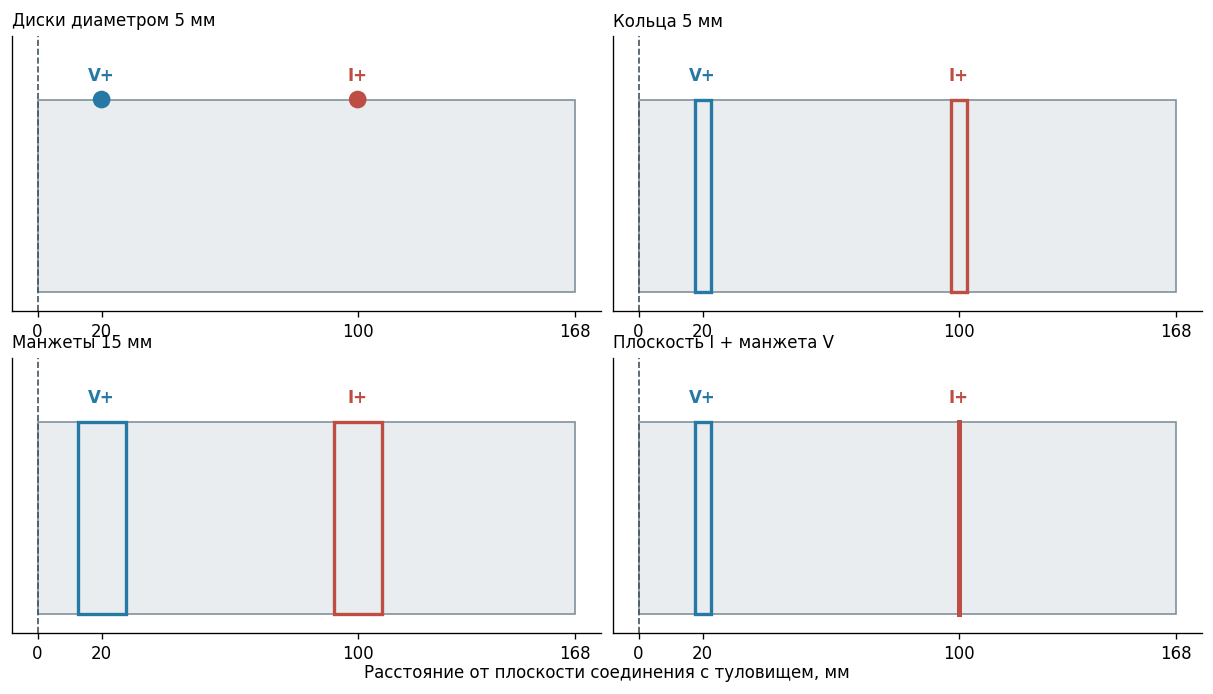

In [2]:
from matplotlib.patches import Rectangle, Circle
fig,axes=plt.subplots(2,2,figsize=(10,5.6),constrained_layout=True)
for ax,kind in zip(axes.flat,study['montage_kinds']):
    ax.add_patch(Rectangle((0,-30),168,60,facecolor='#e9edf0',edgecolor='#81919b'))
    ax.axvline(0,c='#435460',ls='--',lw=1)
    for x,color,role in [(20,'#2679a5','V+'),(100,'#be4e43','I+')]:
        plane=kind=='outer_planes_inner_rings' and role=='I+'
        if kind=='point_disc_5mm':
            ax.add_patch(Circle((x,30),2.5,facecolor=color,edgecolor=color))
        elif plane:
            ax.plot([x,x],[-30,30],c=color,lw=3)
        else:
            width=15 if kind=='wide_cuff_equivalent_area' else 5
            ax.add_patch(Rectangle((x-width/2,-30),width,60,facecolor='none',edgecolor=color,lw=2))
        ax.text(x,36,role,ha='center',color=color,fontweight='bold')
    ax.set_xlim(-8,176);ax.set_ylim(-36,50);ax.set_aspect('equal')
    ax.set_yticks([]);ax.set_xticks([0,20,100,168]);ax.set_title('Плоскость I + манжета V' if kind=='outer_planes_inner_rings' else labels[kind],fontsize=10,loc='left')
fig.supxlabel('Расстояние от плоскости соединения с туловищем, мм',fontsize=10)
plt.show()

**Рисунок 1.** Четыре типа контакта для положения 20/80 мм. Синий цвет обозначает измерительный электрод, красный — токовый. Вертикальная линия токового электрода в нижней правой панели соответствует идеализированной поверхности сечения внутри цилиндра; внутренняя манжета остаётся на его боковой поверхности.

Фактические контактные поверхности дискретны. Контроль включает площадь, число граней и узлов, смещение центра, взаимное непересечение контактов и отступ от соединения и торца цилиндра. Для сечений дополнительно проверяются площадь проекции и осевой разброс граней. В этой модели слово «наружный» описывает положение токового электрода относительно измерительной пары; поверхность плоскостного контакта при этом расположена внутри объёма цилиндра.

## 5. Диапазоны проводимостей и опорное состояние

Все проводимости заданы при частоте 50 кГц в См/м. Используется действительная скалярная проводимость; диэлектрическая составляющая и анизотропия в данной реализации отсутствуют. Изменение частоты не входит в план эксперимента.

Для мягкотканного фона нижний и верхний ориентиры соответствуют жировой ткани и мышце в частотной модели IT’IS/Gabriel. Средний уровень сохраняет прежний эффективный параметр проекта. Такой интервал отражает возможное различие состава и параметризации неоднородной области. Он не означает физиологического превращения одной ткани в другую или изменения её проводимости во всём интервале за короткую запись.

Для сердечной области используются ориентир миокарда, арифметическая середина ориентиров миокарда и крови и ориентир крови. Выбор интервала согласован с допущением об эффективном параметре цельной маски. Закон смешения, ориентация волокон и распределение крови внутри этой маски не установлены; полученный диапазон задаёт набор сценариев эффективной проводимости.

Для лёгких сохранён прежний низкий параметр проекта и добавлены значения IT’IS для наполненного воздухом и ненаполненного лёгкого. Последнее состояние задаёт широкий тканевый ориентир и не приравнивается к обычному физиологическому выдоху. Во всех трёх сценариях анатомия остаётся соответствующей одной КТ на вдохе.

Источником частотных ориентиров служит [IT’IS Tissue Properties Database, версия 5.0](https://itis.swiss/virtual-population/tissue-properties/downloads/database-v5-0); описание модели приведено в разделе [диэлектрических свойств тканей](https://itis.swiss/virtual-population/tissue-properties/database/dielectric-properties). Возможная зависимость оценок мышечной проводимости от направления и неопределённость параметров жировой ткани показаны в исследовании [Kangasmaa и соавт.](https://doi.org/10.1002/bem.22541). Материал [Gabriel, Peyman и Grant](https://doi.org/10.1088/0031-9155/54/16/002) полезен для оценки происхождения низкочастотных тканевых данных; измерения животных тканей и жидкостей вне организма требуют ограничений при переносе на человека. Эти публикации не устанавливают индивидуальные доверительные интервалы для Nix.

Опорное состояние выбрано для сопоставимости с прежним расчётом: средний мягкотканный уровень и нижние уровни сердечной области и лёгких. Оно не совпадает с центром полной сетки и не является оценкой наиболее вероятного физиологического состояния. В таблице ниже приведены все уровни, фиксированные параметры и рассчитанные объёмы электрических классов.

In [3]:
range_table=pd.DataFrame({
 'Область':tissue_labels,
 'Три уровня σ, См/м':['; '.join(f'{x:.6f}' for x in study[k]) for k in ['soft_levels','heart_levels','lung_levels']],
 'Опорная σ, См/м':baseline,
 'Основание':['Жир — прежний фон — мышца','Миокард — условная середина — кровь','Прежний параметр — наполненное воздухом — ненаполненное лёгкое'],
})
display(range_table)
fixed=json.loads((OUT/'fixed_parameters.json').read_text(encoding='utf-8'))
assert len(set(fixed['z_contact_ohm_m2']))==1
display(Markdown(f"Фиксированы: σ кости = {fixed['bone_conductivity_S_m']:.6f} См/м; удельный контактный импеданс {fixed['z_contact_ohm_m2'][0]:.9f} Ом·м²; радиус искусственных рук {fixed['arm_radius_mm']:.0f} мм. Это параметры модели, а не новые измерения контакта или анатомии."))
inventory=pd.read_csv(OUT/'tissue_inventory.csv')
inventory.tissue=inventory.tissue.map({'soft_tissue':'Мягкотканный фон, включая руки','lungs':'Лёгкие','heart':'Цельная сердечная область','bones':'Кости'})
inventory.columns=['Тканевая область модели','Тетраэдры','Объём модели, мл']
display(inventory.round(2))
display(Markdown('Объёмы рассчитаны по назначенным тетраэдрам и не являются новым независимым измерением анатомических объёмов. Отдельной кровяной области в этом разбиении нет.'))

,Область,"Три уровня σ, См/м","Опорная σ, См/м",Основание
0,Мягкотканный фон,0.043274; 0.211498; 0.351828,0.211498,Жир — прежний фон — мышца
1,Сердечная область,0.195435; 0.448118; 0.700801,0.195435,Миокард — условная середина — кровь
2,Лёгкие,0.057449; 0.102656; 0.261966,0.057449,Прежний параметр — наполненное воздухом — ненаполненное лёгкое


Фиксированы: σ кости = 0.020642 См/м; удельный контактный импеданс 0.000159155 Ом·м²; радиус искусственных рук 30 мм. Это параметры модели, а не новые измерения контакта или анатомии.

,Тканевая область модели,Тетраэдры,"Объём модели, мл"
0,"Мягкотканный фон, включая руки",4342549,14328.26
1,Лёгкие,11856,4239.21
2,Цельная сердечная область,1963,782.89
3,Кости,2457,821.16


Объёмы рассчитаны по назначенным тетраэдрам и не являются новым независимым измерением анатомических объёмов. Отдельной кровяной области в этом разбиении нет.

## 6. План вычислительного эксперимента

Для каждой электродной конфигурации выполнено полное перечисление сочетаний трёх уровней трёх проводимостей. Один и тот же набор тканевых состояний используется для всех монтажей; при попарном сравнении меняется только указанная характеристика электродов. Полный набор включает четыре формы контакта и четыре сочетания геометрических расстояний.

$$N_{\sigma}=3^3=27,\qquad N_g=4\cdot2\cdot2=16,\qquad N=N_{\sigma}N_g=432,$$

где $N_{\sigma}$ — число тканевых состояний для одного монтажа; $N_g$ — число монтажей; $N$ — число состояний основной расчётной матрицы.

Эта сетка позволяет отделить сравнение монтажей при одинаковой среде от изменения чувствительности при переходе к другой среде. Она также позволяет исследовать однофакторные сечения и конечные взаимодействия между параметрами. Трёх уровней недостаточно для восстановления произвольной непрерывной зависимости, поиска всех экстремумов или доказательства монотонности между узлами.

Уровни не равноотстоящие, а опорная точка асимметрична относительно границ. Поэтому среднее и медиана по сетке зависят от выбранного плана. Распределения вероятностей параметров, их физиологическая независимость и статистические веса сценариев не задавались. Здесь не вычисляются популяционные вероятности, доверительные интервалы или дисперсионные индексы глобальной чувствительности.

## 7. Электрическая прямая задача

### 7.1. Объёмная проводимость и электрический потенциал

В проводящем объёме рассматривается квазистатическая задача без внутренних источников тока. Проводимость постоянна внутри каждого назначенного компартмента. В используемой действительной модели передаточный импеданс также действителен; фазовый сдвиг между током и напряжением не рассчитывается.

$$\nabla\!\cdot\!\left(\sigma(\mathbf x)\nabla\varphi(\mathbf x)\right)=0\quad\text{в }\Omega,$$

где $\Omega$ — область объёмного проводника; $\mathbf x$ — пространственная координата, м; $\sigma$ — проводимость, См/м; $\varphi$ — потенциал ткани, В. На границах тканевых областей в слабой постановке обеспечиваются непрерывность потенциала и баланс нормального тока. Неоднородность проводимости изменяет распределение поля во всём объёме, поэтому отклик отдельного компартмента зависит и от проводимостей соседних областей.

### 7.2. Поверхностные электроды

Поверхностные контакты описываются полной электродной моделью (CEM, complete electrode model). Каждый идеальный металлический электрод имеет один потенциал, а контакт с тканью обладает конечным удельным импедансом. Для внешней контактной поверхности условия записываются в виде

$$\varphi+z_e\sigma\frac{\partial\varphi}{\partial n}=U_e,
\qquad \int_{\Gamma_e}\sigma\frac{\partial\varphi}{\partial n}\,dS=I_e,
\qquad \sum_e I_e=0,$$

где $\Gamma_e$ — контактная поверхность электрода $e$; $z_e$ — удельный контактный импеданс, Ом·м²; $U_e$ — потенциал электрода, В; $n$ — внешняя нормаль расчётного объёма; $I_e$ — заданный ток, положительный при введении тока из электрода в ткань, А. В такой записи величина $\sigma\partial\varphi/\partial n$ соответствует плотности тока, направленного внутрь ткани, А/м². На остальной внешней поверхности нормальный ток равен нулю.

У измерительных электродов задан нулевой суммарный ток. Это условие допускает локальное перераспределение тока под конечной проводящей контактной поверхностью. Следовательно, измерительный электрод в полной модели не заменяется точкой, пассивно считывающей потенциал невозмущённой ткани. Формальная основа полной электродной модели рассмотрена в работе [Somersalo, Cheney и Isaacson](https://doi.org/10.1137/0152060); конкретные контактные интегралы настоящего расчёта сверены с [реализацией EIDORS](https://eidors3d.sourceforge.net/doc/eidors/solvers/forward/system_mat_fields.html).

### 7.3. Поперечные токовые поверхности

В смешанном монтаже наружные токовые контакты заданы внутренними поверхностями, собранными из граней тетраэдров вблизи требуемого сечения. Объёмные элементы сохраняются: цилиндр не разрезается на электрически несвязанные части и не укорачивается до положения электрода. В дискретную систему добавляется контактная связь выбранных узлов ткани с одним потенциалом электрода.

Это самостоятельная идеализация внутренней контактной поверхности. Стандартные граничные условия внешнего поверхностного электрода не следует буквально трактовать как условия на торце усечённого цилиндра. Эквипотенциален электрод, но при конечном контактном импедансе потенциал ткани на выбранных гранях может различаться. Физическая реализация такой поверхности в эксперименте и её отличие от реального наружного контакта требуют отдельного обоснования.

Объёмный и контактный вклады удобно объединить в слабой форме:

$$\int_{\Omega}\sigma\nabla\varphi\cdot\nabla\psi\,dV
+\sum_e\frac{1}{z_e}\int_{\Gamma_e}(\varphi-U_e)(\psi-W_e)\,dS
=\sum_e I_e W_e,$$

где $\psi$ и $W_e$ — тестовые функции для потенциала ткани и потенциалов электродов; $dV$ и $dS$ — элементы объёма и площади; остальные обозначения определены выше. Для поперечных токовых поверхностей используется та же билинейная контактная связь в дискретной модели. Это описание определяет реализованный расчёт; физическая валидация контакта внутри объёма цилиндра из совпадения алгебраических матриц не следует.

## 8. Конечноэлементная дискретизация и нормировка измерения

Использованы линейные функции формы на тетраэдрах. Геометрические координаты переводятся из миллиметров в метры до сборки электрической матрицы; площади и объёмы в интегралах имеют единицы м² и м³. Один узловой потенциал фиксируется для устранения произвольной аддитивной константы. Измеряемая разность потенциалов от выбора этого уровня отсчёта не зависит.

Для треугольной контактной грани вклад полной электродной модели вычисляется аналитически:

$$K_{c,f}=\frac{A_f}{12z_e}
\begin{pmatrix}
2&1&1&-4\\1&2&1&-4\\1&1&2&-4\\-4&-4&-4&12
\end{pmatrix},$$

где $K_{c,f}$ — локальная контактная матрица, См; $A_f$ — фактическая площадь грани, м²; $z_e$ — удельный контактный импеданс, Ом·м². Первые три степени свободы соответствуют узлам треугольника, четвёртая — потенциалу электрода. Эта формула непосредственно следует из интегрирования произведений линейных функций формы и константы потенциала электрода.

При неизменных сетке и контактах полная матрица аффинно зависит от тканевых проводимостей:

$$K(\boldsymbol\sigma)=\sigma_sK_s+\sigma_hK_h+\sigma_lK_l+\sigma_bK_b+K_c,$$

где $\boldsymbol\sigma=(\sigma_s,\sigma_h,\sigma_l)$ — изменяемые проводимости мягкотканного фона, сердечной области и лёгких, См/м; $\sigma_b$ — фиксированная проводимость кости; $K_s,K_h,K_l,K_b$ — геометрические матрицы объёмных областей, м; $K_c$ — суммарная контактная матрица, См; $K$ — полная матрица проводимости, См. Раздельная сборка объёмных матриц не является приближением низкого порядка относительно уже выбранной FEM-дискретизации: для каждого набора параметров восстанавливается полная система этой сетки.

Для прямого и взаимного измерений решаются системы

$$K u=q_I,\qquad K v=q_V,\qquad Z=q_V^{\mathsf T}u=q_I^{\mathsf T}v,$$

где $q_I$ — безразмерный вектор токовой пары с элементами +1 для I+ и −1 для I−; $q_V$ — аналогичный вектор измерительной пары V+/V−; $u$ и $v$ — векторы потенциалов, нормированных на ток, Ом; $Z$ — передаточный импеданс, Ом; верхний индекс $\mathsf T$ обозначает транспонирование. Все остальные элементы векторов возбуждения равны нулю. Нормировочный ток 1 А используется для удобства линейного расчёта и не задаёт ток реального прибора.

Взаимная задача использует те же четыре контактные поверхности: ток задаётся между V+ и V−, а напряжение считывается между I+ и I−. Равенство двух выражений для $Z$ следует из симметрии матрицы. Оно проверяет согласованность прямого решения, знаков и контактной модели, но не может обнаружить любую физическую ошибку, одинаково присутствующую в обеих задачах.

Системы решены прямым методом Intel oneMKL PARDISO в двойной точности. Перед факторизацией выполнено диагональное масштабирование; невязка затем вычислена в исходной системе. Для каждой из 432 строк параметров выполнено новое решение. Между состояниями сохраняются геометрические матрицы, а не решение потенциала; интерполяция или линейная экстраполяция не заменяют прямую задачу.

## 9. Определения чувствительности и их физический смысл

### 9.1. Размерная производная по проводимости

При фиксированных электродах изменение проводимости компартмента влияет на матрицу системы, но не меняет векторы возбуждения и считывания. Дифференцирование прямой задачи и использование взаимного решения дают

$$D_t=\frac{\partial Z}{\partial\sigma_t}=-v^{\mathsf T}K_tu,$$

где $D_t$ — размерная чувствительность к проводимости компартмента $t$, Ом/(См/м); $K_t=\partial K/\partial\sigma_t$ — его объёмная матрица; $u$ и $v$ — нормированные прямое и взаимное решения. Индекс $t$ принимает значения мягкотканного фона, сердечной области или лёгких. Формула является точной производной выбранной дискретной системы; точность относительно непрерывной задачи дополнительно зависит от сетки.

Для равномерного изменения скалярной проводимости области та же связь имеет интегральную интерпретацию:

$$D_t=-\int_{\Omega_t}\nabla u_I(\mathbf x)\cdot\nabla u_V(\mathbf x)\,dV,$$

где $\Omega_t$ — объём компартмента; $u_I$ и $u_V$ — поля потенциала ткани, нормированные на прямой и взаимный ток, Ом. Подынтегральное выражение описывает пространственное ядро чувствительности. Здесь важны оба поля, а не только плотность тока прямого возбуждения. В произвольном четырёхэлектродном монтаже локальные вклады могут иметь разные знаки и частично компенсироваться. Поэтому один интегральный коэффициент не устанавливает пространственное распределение чувствительности внутри органа. В этой серии сохранены интегральные производные; трёхмерные карты и раздельные положительные и отрицательные вклады не анализировались.

### 9.2. Относительная чувствительность и отклик на малое возмущение

Для сравнения параметров с разными исходными значениями используются относительная чувствительность и размерный отклик на одинаковое процентное изменение:

$$E_t=\frac{\sigma_t}{Z}D_t,\qquad
R_t(1\%)=0{,}01\,\sigma_tD_t,\qquad
\frac{\Delta Z}{Z}\simeq E_t\frac{\Delta\sigma_t}{\sigma_t},$$

где $E_t$ — безразмерная относительная чувствительность; $R_t(1\%)$ — линеаризованное изменение импеданса при увеличении проводимости на 1% от текущего значения, Ом; $\Delta\sigma_t$ и $\Delta Z$ — малые изменения проводимости и импеданса. При увеличении проводимости на 1% число $E_t$ численно равно приближённому изменению $Z$, выраженному в процентах. Для представления $R_t$ в мОм результат в Ом умножается на 1000.

Эти величины отвечают на разные вопросы. Производная $D_t$ связывает импеданс с изменением проводимости в См/м. Величина $R_t(1\%)$ сравнивает размерные отклики на равные относительные возмущения. Коэффициент $E_t$ дополнительно нормирует отклик на базовый импеданс и поэтому может увеличиваться при уменьшении $Z$ без увеличения абсолютного отклика. Во всех таблицах знак сохраняется либо явно указано, что приводится модуль уменьшения.

Локальная линейная аппроксимация не описывает автоматически переход между крайними уровнями широкой сетки. Для большого изменения параметров необходим новый прямой расчёт или проверка погрешности аппроксимации по уже рассчитанным состояниям. Равные процентные изменения разных тканей также не означают равные физиологические амплитуды: в этой работе они являются единым масштабом математического сравнения.

### 9.3. Удельное сопротивление, тканевое содержание и геометрические параметры

Если параметром выбрано удельное сопротивление, необходимо преобразовать производную:

$$\rho_t=\sigma_t^{-1},\qquad
\frac{\partial Z}{\partial\rho_t}=-\frac{D_t}{\rho_t^2},\qquad
E_{\rho,t}=-E_t,$$

где $\rho_t$ — удельное сопротивление, Ом·м; $E_{\rho,t}$ — относительная чувствительность к нему; $D_t$ и $E_t$ относятся к проводимости. Положительное изменение сопротивления и положительное изменение проводимости задают противоположные направления возмущения.

Производные по доле крови, объёму камер, толщине слоя или координатам органа являются другими величинами. Для их вычисления необходимо задать зависимость электрических свойств и/или геометрии от выбранного параметра. Численно приравнивать производную по проводимости к производной по объёму крови нельзя. Если изменение доли ткани описывается только через эффективную проводимость, требуется независимо обоснованный закон смешения; если меняется граница, необходимо учитывать изменение геометрии.

Для общего параметра $p$ полезна более полная формула:

$$\frac{dZ}{dp}=\left(\frac{dq_V}{dp}\right)^{\mathsf T}u
+v^{\mathsf T}\frac{dq_I}{dp}
-v^{\mathsf T}\frac{dK}{dp}u,$$

где $p$ — рассматриваемый параметр; $K,q_I,q_V,u,v,Z$ определены в прямой задаче. Формула предполагает согласованное дифференцируемое представление системы с фиксированным пространством степеней свободы. При перемещении границ, изменении состава контактных граней или перестроении сетки потребуется отдельная процедура геометрического дифференцирования либо сопоставимые конечные возмущения. В текущем расчёте изменяется только объёмная проводимость, поэтому первые два слагаемых равны нулю.

## 10. Численная верификация и область её действия

Для контроля формы элементов используется безразмерный показатель SICN: малые положительные значения указывают на плохую форму тетраэдра. Ниже отдельно приведены его минимальное значение и число элементов ниже выбранного порога.

Контроль организован по нескольким независимым по назначению уровням. Геометрические проверки устанавливают, какие поверхности и объёмы фактически участвуют в расчёте. Сопоставление матриц проверяет реализацию контактных интегралов. Невязка и взаимность проверяют решение линейной задачи. Конечные разности проверяют вычисление производной. Сравнение двух решателей проверяет воспроизводимость результата разными численными алгоритмами. Каждый уровень имеет ограниченную область действия.

Относительная невязка вычисляется для двух правых частей совместно, а ошибка взаимности — по двум определениям передаточного импеданса:

$$r=\frac{\|KX-Q\|_F}{\|Q\|_F},\qquad
\varepsilon_{\mathrm{rec}}=\frac{|Z_I-Z_V|}{\max(|Z_I|,|Z_V|)},$$

где $X=[u,v]$ — матрица двух решений; $Q=[q_I,q_V]$ — соответствующие правые части; $\|\cdot\|_F$ — норма Фробениуса; $Z_I$ и $Z_V$ — прямой и взаимный импедансы. В основной серии приняты критерии $r<10^{-7}$ и $\varepsilon_{\mathrm{rec}}<10^{-8}$. При будущих монтажах с импедансом, близким к нулю, относительный критерий потребует дополнительного абсолютного масштаба.

Полная аффинная сборка сопоставлена с EIDORS для каждого из 16 монтажей; допустимое относительное расхождение матриц равно $10^{-12}$. Производные проверены центральной конечной разностью:

$$D_t^{\mathrm{FD}}(h)=\frac{Z(\boldsymbol\sigma_0+h\mathbf e_t)-Z(\boldsymbol\sigma_0-h\mathbf e_t)}{2h},\qquad
\varepsilon_{D,t}=\frac{|D_t^{\mathrm{FD}}-D_t|}{\max(|D_t|,D_{\min})},$$

где $\boldsymbol\sigma_0$ — опорный набор проводимостей; $\mathbf e_t$ — единичный вектор изменяемого параметра; $h$ — шаг по проводимости, См/м; $D_t^{\mathrm{FD}}$ — конечно-разностная оценка; $D_{\min}=10^{-10}$ Ом/(См/м) — защитный масштаб знаменателя в реализации. Для данной серии все проверяемые производные значительно превышают этот масштаб по модулю.

Использованы шаги 1% и 0,5% от опорной проводимости, четыре формы контакта и три компартмента при положении 20/80 мм: всего 24 сопоставления производных и 48 вспомогательных возмущённых прямых решений. При нижнем опорном уровне центральный отрицательный шаг выходит за границу основной трёхуровневой сетки; это численная проверка в локальной окрестности положительной проводимости, а не дополнительный физиологический сценарий. Допустимое расхождение производной составляет 0,2%. Проверка не выполнена во всех 432 состояниях, что ограничивает область прямого конечно-разностного контроля.

Дополнительно один опорный смешанный монтаж решён методом сопряжённых градиентов с алгебраическим многосеточным предобусловливанием на той же полной сетке. Сопоставление с PARDISO характеризует согласованность двух решателей одной дискретной задачи. Сравнение с прежним исследованием охватывает 12 неизменённых поверхностных монтажей; отклонённая четырёхплоскостная конфигурация в него не входит.

In [4]:
independent=json.loads((OUT/'independent_solver_qc.json').read_text(encoding='utf-8'))
assert independent['relative_difference']<1e-8
display(Markdown(f"Независимая проверка опорного смешанного монтажа: PARDISO и сопряжённые градиенты с многосеточным предобусловливанием дали относительное расхождение Z **{independent['relative_difference']:.2g}**. Обе проверки решают одну дискретную FEM-задачу и не являются внешней физической валидацией."))
quality=acceptance['mesh_shape_quality']
basic=acceptance['mesh_basic_quality']
display(Markdown(f"Сетка содержит {basic['nodes']:,} узлов и {basic['tetrahedra']:,} тетраэдров. Вырожденных и инвертированных элементов нет, но число элементов с SICN ≤ 0,001 составляет **{quality['count_le_0_001']}**; минимум качества {quality['minimum']:.3g}. Численный контроль фиксированной сетки пройден, сеточная сходимость тканевых чувствительностей не проверена. Старый паспорт приёмки относится к прежнему набору контактов; все 64 контакта текущей серии проверены отдельно."))
qc=pd.DataFrame({
 'Проверка':['Состояний','Контактных поверхностей','Максимальная ошибка взаимности','Максимальная относительная невязка','Максимальное расхождение с матрицей EIDORS','Максимальная относительная ошибка производной'],
 'Результат':[len(df),len(patches),df.reciprocity_relative_error.max(),df.relative_residual.max(),df.matrix_relative_error.max(),fd.relative_error.max()],
})
qc['Результат']=[str(len(df)),str(len(patches)),f'{df.reciprocity_relative_error.max():.6g}',f'{df.relative_residual.max():.6g}',f'{df.matrix_relative_error.max():.6g}',f'{fd.relative_error.max():.6g}']
display(qc)
display(Markdown(f"Двенадцать неизменённых поверхностных монтажей воспроизвели исходные опорные значения 40.02; максимальное относительное отличие **{regression.relative_difference.max():.2g}**. Исторические четыре плоскости исключены из этой проверки и из матрицы чувствительности."))
plane_area=patches.loc[is_plane,'area_ratio']
plane_projection=patches.loc[is_plane,'projected_cross_section_area_ratio']
display(Markdown(f'Для наружных плоскостей фактическая площадь граней составляет **{plane_area.min():.3f}–{plane_area.max():.3f}** номинальной площади сечения, а площадь проекции — **{plane_projection.min():.3f}–{plane_projection.max():.3f}**. Контактная матрица интегрируется по фактическим граням. При фиксированном удельном контактном импедансе это меняет интегральную контактную проводимость; компенсация площади не вводилась. Следовательно, результат относится к данной дискретной CEM-идеализации.'))
geometry=patches.groupby(['electrode_kind','contact_geometry'],as_index=False).agg(contacts=('label','size'),area_ratio_min=('area_ratio','min'),area_ratio_max=('area_ratio','max'))
geometry.electrode_kind=geometry.electrode_kind.map(short)
geometry.contact_geometry=geometry.contact_geometry.replace({**short,'surface_cuff':'Поверхностная манжета','internal_plane':'Внутренняя поверхность сечения'})
geometry.columns=['Схема','Контактная поверхность','Контактов','Мин. A/Aном','Макс. A/Aном']
display(geometry.round(4))
warning_rows=df[df.solver_warning.notna()|df.solver_warning_message.notna()]
if len(warning_rows):
    display(Markdown('**Численные предупреждения:** приведены ниже; выполнение критериев невязки и взаимности не отменяет их рассмотрения.'))
    display(warning_rows[['montage','case_index','solver_warning','solver_warning_message']].drop_duplicates())

Независимая проверка опорного смешанного монтажа: PARDISO и сопряжённые градиенты с многосеточным предобусловливанием дали относительное расхождение Z **2.3e-11**. Обе проверки решают одну дискретную FEM-задачу и не являются внешней физической валидацией.

Сетка содержит 752,827 узлов и 4,358,825 тетраэдров. Вырожденных и инвертированных элементов нет, но число элементов с SICN ≤ 0,001 составляет **701**; минимум качества 4.35e-07. Численный контроль фиксированной сетки пройден, сеточная сходимость тканевых чувствительностей не проверена. Старый паспорт приёмки относится к прежнему набору контактов; все 64 контакта текущей серии проверены отдельно.

,Проверка,Результат
0,Состояний,432
1,Контактных поверхностей,64
2,Максимальная ошибка взаимности,5.26748e-10
3,Максимальная относительная невязка,2.34149e-10
4,Максимальное расхождение с матрицей EIDORS,1.55155e-16
5,Максимальная относительная ошибка производной,9.45654e-05


Двенадцать неизменённых поверхностных монтажей воспроизвели исходные опорные значения 40.02; максимальное относительное отличие **7e-10**. Исторические четыре плоскости исключены из этой проверки и из матрицы чувствительности.

Для наружных плоскостей фактическая площадь граней составляет **1.569–1.634** номинальной площади сечения, а площадь проекции — **1.011–1.017**. Контактная матрица интегрируется по фактическим граням. При фиксированном удельном контактном импедансе это меняет интегральную контактную проводимость; компенсация площади не вводилась. Следовательно, результат относится к данной дискретной CEM-идеализации.

,Схема,Контактная поверхность,Контактов,Мин. A/Aном,Макс. A/Aном
0,Кольца,Кольца,16,0.9967,0.9968
1,Плоскости + кольца,Внутренняя поверхность сечения,8,1.5686,1.6335
2,Плоскости + кольца,Поверхностная манжета,8,0.9967,0.9968
3,Диски,Диски,16,1.0125,1.0379
4,Широкие манжеты,Широкие манжеты,16,0.9967,0.9968


Численные критерии выполнены на фиксированной сетке. При этом большое число элементов само по себе не доказывает достаточного разрешения границ органов или контактных поверхностей. Наличие элементов низкого качества требует проверки сеточной сходимости именно импедансов и производных; достигнутая малая невязка линейной системы такую проверку не заменяет.

Для поперечных токовых поверхностей отдельно существенна разница между фактической площадью выбранных граней и площадью их проекции. Контактная проводимость интегрируется по фактической площади. При неизменном удельном контактном импедансе увеличение площади увеличивает интегральную проводимость контакта. Компенсация этого эффекта в настоящей серии не вводилась. Поэтому сравнение смешанного и поверхностного монтажа относится к указанной дискретной реализации, а не к абстрактным идеально плоским электродам одинаковой эффективной площади.

Пройденные проверки подтверждают работоспособность расчётной процедуры в заявленной области. Они не устанавливают погрешность коэффициентов относительно реального человека и не завершают экспериментальную валидацию методики.

## 11. Чувствительность в опорном состоянии

Первое сравнение выполнено при одном и том же наборе тканевых проводимостей. Различия между строками следующей таблицы относятся к форме или положению контактов. Опорный сердечный параметр находится на нижней границе выбранного интервала; это условие сопоставимости, а не оценка состава сердца.

В таблице приведены базовый импеданс и относительные чувствительности всех 16 монтажей. Далее размерные производные и отклики на увеличение проводимости на 1% сведены по компартментам. Численные диапазоны являются минимумами и максимумами по конечному набору монтажей; они не характеризуют разброс повторных измерений или доверительную неопределённость.

In [5]:
show=base[['electrode_kind','inner_mm','outer_mm','Z_direct_ohm','elasticity_soft','elasticity_heart','elasticity_lung']].copy()
show.electrode_kind=show.electrode_kind.map(labels)
show.columns=['Контакт','От туловища, мм','Между электродами, мм','Z, Ом','E мягкие ткани','E сердце','E лёгкие']
show.index=base.montage_index.to_numpy()
show.index.name='Монтаж'
display(show.round(6))

,Контакт,"От туловища, мм","Между электродами, мм","Z, Ом",E мягкие ткани,E сердце,E лёгкие
Монтаж,,,,,,,
1,Диски диаметром 5 мм,20,80,191.993105,-0.957689,-0.003553,-0.036677
2,Кольца 5 мм,20,80,189.241705,-0.956500,-0.003605,-0.037153
3,Манжеты 15 мм,20,80,180.239071,-0.953231,-0.003785,-0.039008
4,Наружные плоскости + внутренние кольца,20,80,189.241237,-0.956500,-0.003605,-0.037153
5,Диски диаметром 5 мм,20,100,191.583804,-0.957596,-0.003560,-0.036756
6,Кольца 5 мм,20,100,189.241274,-0.956500,-0.003605,-0.037153
7,Манжеты 15 мм,20,100,180.238492,-0.953231,-0.003785,-0.039008
8,Наружные плоскости + внутренние кольца,20,100,189.241237,-0.956500,-0.003605,-0.037153
9,Диски диаметром 5 мм,40,80,259.472058,-0.968600,-0.002629,-0.027104


In [6]:
summary_rows=[]
for scope,frame in [('Опорное состояние',base),('Вся матрица',df)]:
    for t,label in zip(tissues,tissue_labels):
        D=frame[f'dZ_dsigma_{t}'];E=frame[f'elasticity_{t}']
        R=.01*frame[f'sigma_{t}']*D*1000
        summary_rows.append(dict(scope=scope,tissue=t,label=label,D_min=D.min(),D_max=D.max(),E_min=E.min(),E_max=E.max(),R_min=R.min(),R_max=R.max()))
sensitivity_summary=pd.DataFrame(summary_rows)
sensitivity_summary.to_csv(ANALYSIS/'compartment_sensitivity_summary.csv',index=False)
def show_sensitivity_scope(scope):
    rows=sensitivity_summary[sensitivity_summary.scope==scope]
    display(pd.DataFrame({
        'Компартмент':rows.label.to_numpy(),
        'D, Ом/(См/м)': [f'от {a:.6g} до {b:.6g}' for a,b in zip(rows.D_min,rows.D_max)],
        'R(1%), мОм':[f'от {a:.6g} до {b:.6g}' for a,b in zip(rows.R_min,rows.R_max)],
        'E':[f'от {a:.6g} до {b:.6g}' for a,b in zip(rows.E_min,rows.E_max)]}))
show_sensitivity_scope('Опорное состояние')
soft_heart=(base.dZ_dsigma_soft*baseline[0]/(base.dZ_dsigma_heart*baseline[1])).abs()
lung_heart=(base.dZ_dsigma_lung*baseline[2]/(base.dZ_dsigma_heart*baseline[1])).abs()
display(Markdown(f'При равных относительных возмущениях в опорной точке модуль мягкотканного отклика превышает сердечный в **{soft_heart.min():.1f}–{soft_heart.max():.1f} раза**, лёгочного — в **{lung_heart.min():.2f}–{lung_heart.max():.2f} раза**. Эти отношения вычислены попарно для каждого монтажа.'))

,Компартмент,"D, Ом/(См/м)","R(1%), мОм",E
0,Мягкотканный фон,от -1188.31 до -812.343,от -2513.25 до -1718.09,от -0.9686 до -0.953231
1,Сердечная область,от -3.49091 до -3.49004,от -6.82247 до -6.82077,от -0.0037852 до -0.00262872
2,Лёгкие,от -122.574 до -122.383,от -70.4179 до -70.3081,от -0.0390084 до -0.0271041


При равных относительных возмущениях в опорной точке модуль мягкотканного отклика превышает сердечный в **251.8–368.5 раза**, лёгочного — в **10.31–10.32 раза**. Эти отношения вычислены попарно для каждого монтажа.

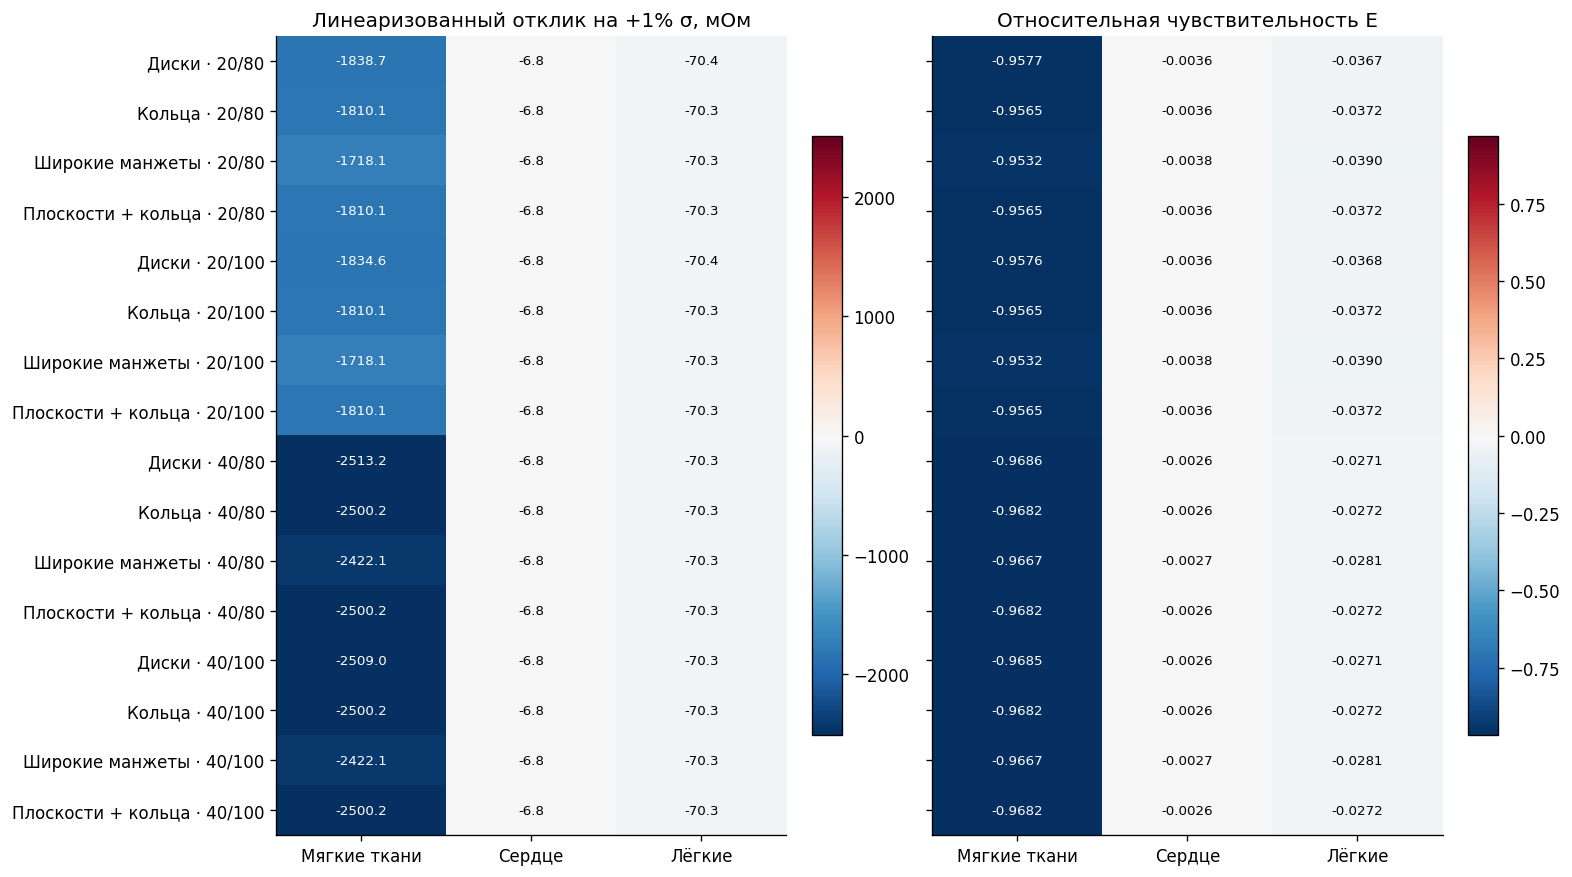

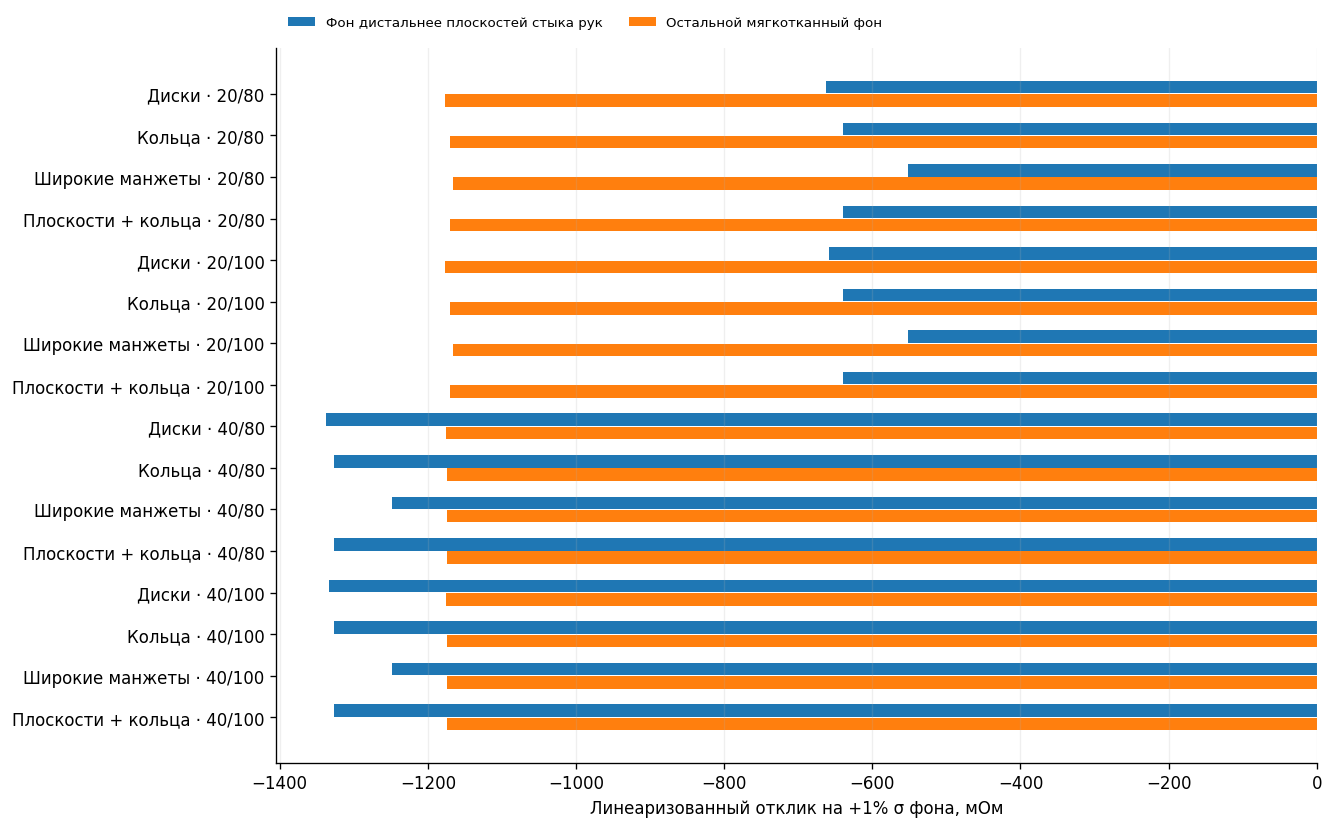

In [7]:
E=base[[f'elasticity_{t}' for t in tissues]].to_numpy()
dZ=base[[f'dZ_dsigma_{t}' for t in tissues]].to_numpy()*baseline[None,:]*.01*1000
fig,axes=plt.subplots(1,2,figsize=(13,7.2),constrained_layout=True)
for ax,values,title,fmt in zip(axes,[dZ,E],['Линеаризованный отклик на +1% σ, мОм','Относительная чувствительность E'],['.1f','.4f']):
    vmax=np.abs(values).max();im=ax.imshow(values,cmap='RdBu_r',vmin=-vmax,vmax=vmax,aspect='auto')
    ax.set_xticks(range(3),['Мягкие ткани','Сердце','Лёгкие']);ax.set_yticks(range(16),base.label)
    ax.set_title(title)
    if ax is axes[1]:ax.set_yticklabels([])
    for i in range(16):
        for j in range(3):ax.text(j,i,format(values[i,j],fmt),ha='center',va='center',fontsize=8,color='white' if abs(values[i,j])>vmax*.65 else 'black')
    fig.colorbar(im,ax=ax,shrink=.75)
plt.show()
# All background, distal artificial-arm background and torso background.
arm_response=base.dZ_dsigma_soft_distal.to_numpy()*baseline[0]*.01*1000
torso_response=base.dZ_dsigma_soft_torso.to_numpy()*baseline[0]*.01*1000
fig,ax=plt.subplots(figsize=(11,6.8),constrained_layout=True)
y=np.arange(16)
ax.barh(y-.16,arm_response,height=.30,label='Фон дистальнее плоскостей стыка рук')
ax.barh(y+.16,torso_response,height=.30,label='Остальной мягкотканный фон')
ax.set_yticks(y,base.label);ax.invert_yaxis();ax.set_xlabel('Линеаризованный отклик на +1% σ фона, мОм');ax.legend(fontsize=8,loc='lower left',bbox_to_anchor=(0,1.01),ncol=2,frameon=False);ax.grid(axis='x',alpha=.2)
plt.show()

**Рисунок 2.** Размерный отклик на увеличение проводимости на 1% и относительная чувствительность в опорном состоянии. Отрицательный знак означает уменьшение передаточного импеданса при выбранной полярности измерения. Единая цветовая шкала внутри каждой панели облегчает сравнение компартментов; числовые подписи сохраняют сведения о малом сердечном отклике на фоне значительно большего мягкотканного.

**Рисунок 3.** Разложение мягкотканного отклика на область дистальнее плоскостей соединения рук и остальной фон. Обе производные вычислены при общей проводимости фона; их алгебраическая сумма равна производной всего мягкотканного компартмента. Это разложение позволяет проверить, насколько результат связан с искусственно добавленными участками геометрии.

В опорной точке у всех монтажей наибольший отклик на равное процентное возмущение связан с мягкотканным фоном, затем следуют лёгкие и сердечная область. Такая иерархия относится к принятой параметризации и геометрии. Поскольку реальная амплитуда изменений разных тканей не задана, из неё нельзя получить долю каждого источника в зарегистрированном пульсовом сигнале.

Абсолютные отклики сердечной области у монтажей близки, тогда как относительные коэффициенты заметнее различаются из-за нормировки на разный базовый импеданс. При сравнении электродных сборок для регистрации малого изменения напряжения первичным результатом поэтому должен оставаться размерный коэффициент, дополненный моделью реального возбуждения и измерительной погрешности.

## 12. Влияние формы и положения электродов

Для выделения геометрического эффекта сравниваются пары состояний с одинаковыми проводимостями. В первой таблице изменяется расстояние от соединения туловища с рукой до внутренней пары: 20→40 мм. Разнос I–V сохраняется, поэтому наружные электроды смещаются на те же 20 мм. Разность сердечных откликов относится к одному и тому же относительному возмущению проводимости, а не к разнице исходных параметров сердца.

Во второй таблице изменяется только разнос I–V: 80→100 мм при фиксированном положении измерительной пары. Эти два геометрических эксперимента необходимо различать: они изменяют разные части измерительной конфигурации.

In [8]:
geo=base[base.inner_mm==20].merge(base[base.inner_mm==40],on=['electrode_kind','outer_mm'],suffixes=('_20','_40'))
geo['delta_Z']=geo.Z_direct_ohm_40-geo.Z_direct_ohm_20
geo['delta_R_heart_mohm']=.01*baseline[1]*1000*(geo.dZ_dsigma_heart_40-geo.dZ_dsigma_heart_20)
geo.to_csv(ANALYSIS/'inner_distance_comparison.csv',index=False)
with pd.option_context('display.float_format',lambda x:f'{x:.6g}'):
    display(pd.DataFrame({'Контакт':geo.electrode_kind.map(short),'Разнос I–V, мм':geo.outer_mm,'Изменение Z, Ом':geo.delta_Z,'Изменение R сердца, мОм':geo.delta_R_heart_mohm}))
outer=base[base.outer_mm==80].merge(base[base.outer_mm==100],on=['electrode_kind','inner_mm'],suffixes=('_80','_100'))
outer['delta_Z']=outer.Z_direct_ohm_100-outer.Z_direct_ohm_80
outer['delta_R_heart_mohm']=.01*baseline[1]*1000*(outer.dZ_dsigma_heart_100-outer.dZ_dsigma_heart_80)
outer.to_csv(ANALYSIS/'outer_distance_comparison.csv',index=False)
with pd.option_context('display.float_format',lambda x:f'{x:.6g}'):
    display(pd.DataFrame({'Контакт':outer.electrode_kind.map(short),'Внутреннее расстояние, мм':outer.inner_mm,'Изменение Z, Ом':outer.delta_Z,'Изменение R сердца, мОм':outer.delta_R_heart_mohm}))
comparison=df[df.electrode_kind=='outer_planes_inner_rings'].merge(df[df.electrode_kind=='circumferential_ring'],on=['inner_mm','outer_mm','case_index'],suffixes=('_mixed','_ring'))
assert len(comparison)==108
mixed_dz=(comparison.Z_direct_ohm_mixed-comparison.Z_direct_ohm_ring).abs().max()
mixed_de=(comparison.elasticity_heart_mixed-comparison.elasticity_heart_ring).abs().max()
comparison.to_csv(ANALYSIS/'mixed_vs_ring_comparison.csv',index=False)
heart_base=.01*baseline[1]*1000*base.dZ_dsigma_heart
arm_fraction=(base.dZ_dsigma_soft_distal/base.dZ_dsigma_soft).abs()
assert np.allclose(df.dZ_dsigma_soft,df.dZ_dsigma_soft_distal+df.dZ_dsigma_soft_torso,rtol=1e-10,atol=1e-9)
display(Markdown(f"""**Результат геометрического сравнения.** При переходе внутреннего расстояния от 20 к 40 мм базовый импеданс увеличивается на **{geo.delta_Z.min():.3f}–{geo.delta_Z.max():.3f} Ом**. Максимальное изменение сердечного отклика на +1% проводимости составляет лишь **{geo.delta_R_heart_mohm.abs().max():.6f} мОм** при исходном отклике от {heart_base.min():.4f} до {heart_base.max():.4f} мОм.

Во всех 108 совпадающих состояниях максимальное различие смешанного монтажа и узких манжет равно **{mixed_dz:.8f} Ом** по импедансу и **{mixed_de:.3g}** по относительной сердечной чувствительности. В опорной точке отношение модуля дистальной фоновой производной к модулю производной всего фона находится в пределах **{arm_fraction.min():.3f}–{arm_fraction.max():.3f}**."""))
# Compare montage-induced spread separately at each common tissue state.
spread_rows=[]
for t in tissues:
    temp=df.assign(response=.01*df[f'sigma_{t}']*df[f'dZ_dsigma_{t}']*1000)
    for case,g in temp.groupby('case_index'):
        vals=g.response.to_numpy()
        spread_rows.append({'tissue':t,'case_index':case,'response_span_mohm':np.ptp(vals),'relative_span_pct':100*np.ptp(vals)/np.mean(np.abs(vals))})
spread=pd.DataFrame(spread_rows)
spread.to_csv(ANALYSIS/'montage_response_spread_by_state.csv',index=False)
spread_summary=spread.groupby('tissue',sort=False).agg(max_span=('response_span_mohm','max'),max_relative_span=('relative_span_pct','max')).reindex(tissues)
display(pd.DataFrame({'Компартмент':tissue_labels,'Макс. размах R между 16 монтажами, мОм':spread_summary.max_span.to_numpy(),'Макс. размах относительно среднего |R|, %':spread_summary.max_relative_span.to_numpy()}).round(6))

,Контакт,"Разнос I–V, мм","Изменение Z, Ом","Изменение R сердца, мОм"
0,Диски,80,67.479,-3.35187e-05
1,Кольца,80,69.0052,-0.000151108
2,Широкие манжеты,80,70.3279,-6.93478e-05
3,Плоскости + кольца,80,69.0052,-0.000151073
4,Диски,100,67.4654,-8.58619e-06
5,Кольца,100,69.0052,-0.00015105
6,Широкие манжеты,100,70.3278,-6.93694e-05
7,Плоскости + кольца,100,69.0052,-0.000151048


,Контакт,"Внутреннее расстояние, мм","Изменение Z, Ом","Изменение R сердца, мОм"
0,Диски,20,-0.409301,-3.74992e-05
1,Кольца,20,-0.000430642,-5.04528e-08
2,Широкие манжеты,20,-0.000578624,2.27377e-08
3,Плоскости + кольца,20,3.23504e-08,-1.43131e-08
4,Диски,40,-0.422871,-1.25667e-05
5,Кольца,40,-0.000483461,7.04346e-09
6,Широкие манжеты,40,-0.000677245,1.09629e-09
7,Плоскости + кольца,40,4.75136e-07,1.08022e-08


**Результат геометрического сравнения.** При переходе внутреннего расстояния от 20 к 40 мм базовый импеданс увеличивается на **67.465–70.328 Ом**. Максимальное изменение сердечного отклика на +1% проводимости составляет лишь **0.000151 мОм** при исходном отклике от -6.8225 до -6.8208 мОм.

Во всех 108 совпадающих состояниях максимальное различие смешанного монтажа и узких манжет равно **0.00257326 Ом** по импедансу и **1.74e-08** по относительной сердечной чувствительности. В опорной точке отношение модуля дистальной фоновой производной к модулю производной всего фона находится в пределах **0.321–0.532**.

,Компартмент,"Макс. размах R между 16 монтажами, мОм","Макс. размах относительно среднего |R|, %"
0,Мягкотканный фон,3885.470777,42.555043
1,Сердечная область,0.159139,0.403420
2,Лёгкие,2.478330,0.917913


Различие базовых импедансов сопровождается значительным изменением фонового отклика и очень малым изменением сердечного. Это наблюдение согласуется с существенным вкладом модельных участков рук в интегральную мягкотканную производную. Оно не доказывает простую последовательную электрическую схему «руки плюс туловище»: распределение поля остаётся трёхмерным и зависит от всех проводимостей.

Близость смешанного и кольцевого монтажей означает, что в исследованных положениях замена наружных токовых контактов не дала выраженного выигрыша по выбранной сердечной чувствительности. Этот вывод нельзя переносить на контакты на грудной клетке, другую анатомию, иной радиус рук или другие измерительные пары. Проверка таких вариантов должна выполняться с их собственными прямыми и взаимными полями.

Последняя таблица отделяет влияние монтажа от влияния тканей: сначала размах отклика вычисляется между 16 монтажами внутри одного тканевого состояния, затем берётся его максимум по 27 состояниям. Максимум абсолютного размаха и максимум относительного размаха могут достигаться в разных состояниях. Относительный размах нормирован на средний модуль отклика внутри соответствующего состояния; он не является оценкой погрешности измерения.

## 13. Зависимость отклика от тканевого состояния

Следующие кривые являются однофакторными сечениями основной матрицы для положения 20/80 мм. В каждой панели меняется только указанная проводимость, две остальные сохраняют опорные значения. Все точки получены прямым решением FEM-задачи. Соединяющие отрезки служат для чтения графика и не определяют физический закон между узлами.

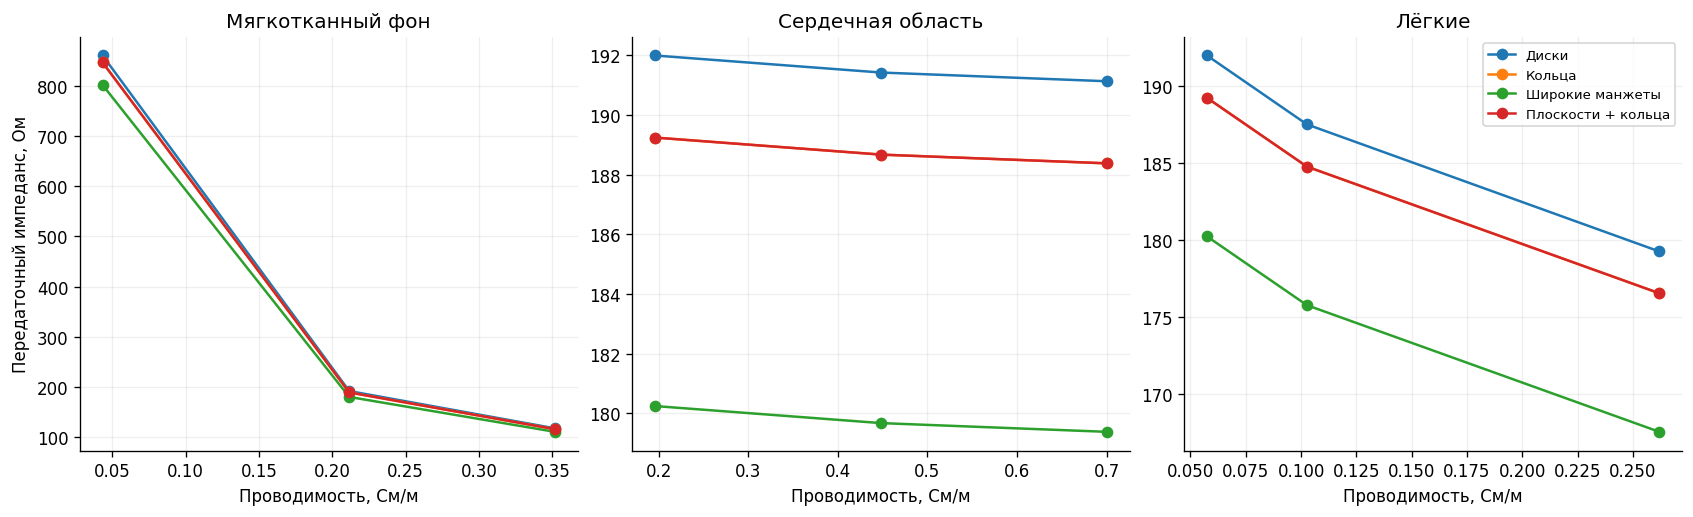

In [9]:
fig,axes=plt.subplots(1,3,figsize=(14,4.2),constrained_layout=True)
for t,ax in enumerate(axes):
    other=[i for i in range(3) if i!=t]
    sel=(df.inner_mm==20)&(df.outer_mm==80)
    for j in other:sel &= np.isclose(df[f'sigma_{tissues[j]}'],baseline[j])
    for kind in study['montage_kinds']:
        g=df[sel&(df.electrode_kind==kind)].sort_values(f'sigma_{tissues[t]}')
        ax.plot(g[f'sigma_{tissues[t]}'],g.Z_direct_ohm,'o-',label=short[kind])
    ax.set_xlabel('Проводимость, См/м');ax.set_title(tissue_labels[t]);ax.grid(alpha=.2)
axes[0].set_ylabel('Передаточный импеданс, Ом');axes[-1].legend(fontsize=8)
plt.show()

**Рисунок 4.** Однофакторные зависимости передаточного импеданса от проводимости мягкотканного фона, сердечной области и лёгких. Вертикальные масштабы панелей различаются и соответствуют их собственным диапазонам импеданса. Почти совпадающие кривые узких манжет и смешанного монтажа перекрывают друг друга. Выраженное изменение наклона между уровнями показывает необходимость различать локальную производную и конечное изменение параметра.

Для количественной проверки применимости одной опорной линейной модели все сохранённые состояния сопоставляются с её предсказанием:

$$Z_{\mathrm{lin}}(\boldsymbol\sigma)=Z_0+\sum_tD_{t,0}(\sigma_t-\sigma_{t,0}),\qquad
\varepsilon_{\mathrm{lin}}=\frac{|Z-Z_{\mathrm{lin}}|}{|Z|},$$

где $Z_0$, $D_{t,0}$ и $\sigma_{t,0}$ — импеданс, производная и проводимость в опорной точке конкретного монтажа; $Z$ — прямое решение в рассматриваемом состоянии; $Z_{\mathrm{lin}}$ — линейное предсказание; $\varepsilon_{\mathrm{lin}}$ — его относительное расхождение с прямым решением. Эта проверка использует уже рассчитанную матрицу и характеризует ошибку экстраполяции, а не ошибку FEM-решателя.

,Монтаж,"Макс. расхождение линейного Z, %","Медиана расхождения по сетке, %"
0,Диски · 20/80,61.099,44.752
1,Кольца · 20/80,61.066,44.711
2,Широкие манжеты · 20/80,61.767,44.662
3,Плоскости + кольца · 20/80,61.066,44.711
4,Диски · 20/100,61.094,44.753
5,Кольца · 20/100,61.066,44.711
6,Широкие манжеты · 20/100,61.767,44.662
7,Плоскости + кольца · 20/100,61.066,44.711
8,Диски · 40/80,61.730,44.550
9,Кольца · 40/80,61.723,44.530


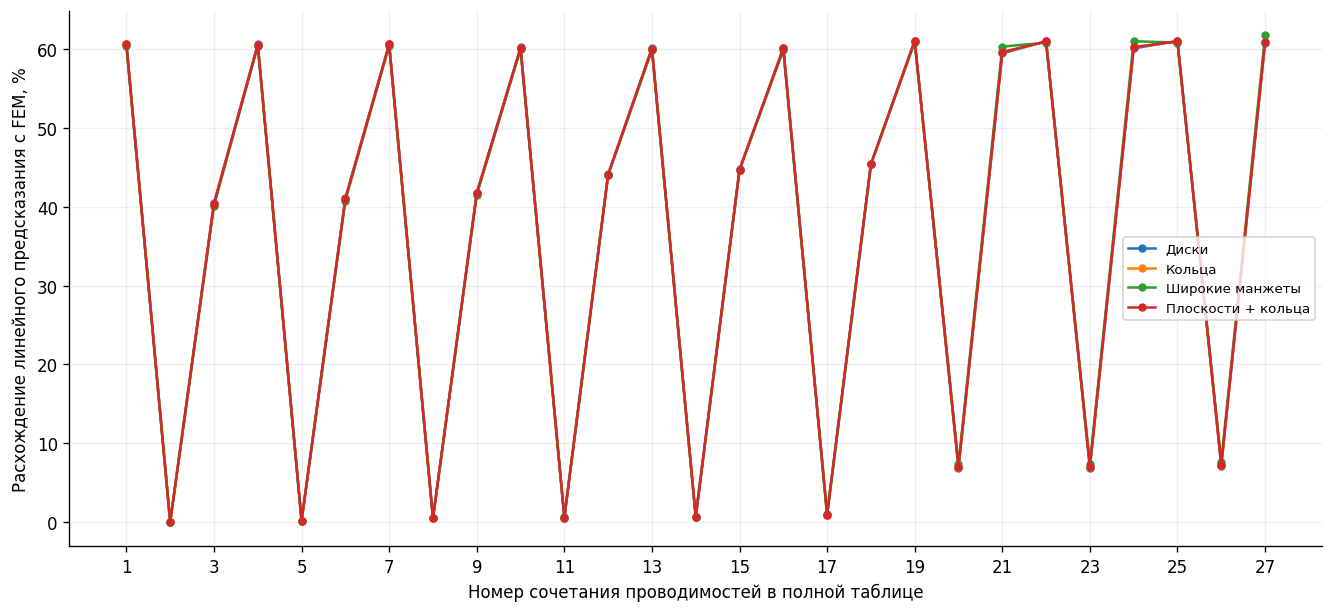

На всей сетке максимальное относительное расхождение опорной линейной аппроксимации составляет **61.77%**. Это значение относится к широкому диапазону параметров; оно не характеризует ошибку локальной производной при бесконечно малом возмущении.

In [10]:
lin=df.merge(base[['montage','Z_direct_ohm',*[f'dZ_dsigma_{t}' for t in tissues]]],on='montage',suffixes=('','_baseline'))
lin['Z_linear_ohm']=lin.Z_direct_ohm_baseline
for j,t in enumerate(tissues):
    lin['Z_linear_ohm']+=lin[f'dZ_dsigma_{t}_baseline']*(lin[f'sigma_{t}']-baseline[j])
lin['linearization_relative_error']=(lin.Z_direct_ohm-lin.Z_linear_ohm).abs()/lin.Z_direct_ohm.abs()
lin.to_csv(ANALYSIS/'baseline_linearization_check.csv',index=False)
lin_summary=lin.groupby('montage_index',as_index=False).agg(max_abs_error=('linearization_relative_error','max'),median_error=('linearization_relative_error','median'))
display(pd.DataFrame({'Монтаж':base.label.to_numpy(),'Макс. расхождение линейного Z, %':100*lin_summary.max_abs_error,'Медиана расхождения по сетке, %':100*lin_summary.median_error}).round(3))
fig,ax=plt.subplots(figsize=(11,5),constrained_layout=True)
for kind in study['montage_kinds']:
    g=lin[(lin.electrode_kind==kind)&(lin.inner_mm==20)&(lin.outer_mm==80)].sort_values('case_index')
    ax.plot(g.case_index,100*g.linearization_relative_error,'o-',ms=4,label=short[kind])
ax.set_xlabel('Номер сочетания проводимостей в полной таблице');ax.set_ylabel('Расхождение линейного предсказания с FEM, %')
ax.set_xticks(range(1,28,2));ax.grid(alpha=.2);ax.legend(fontsize=8)
plt.show()
display(Markdown(f'На всей сетке максимальное относительное расхождение опорной линейной аппроксимации составляет **{100*lin.linearization_relative_error.max():.2f}%**. Это значение относится к широкому диапазону параметров; оно не характеризует ошибку локальной производной при бесконечно малом возмущении.'))

**Рисунок 5.** Расхождение опорной линейной аппроксимации и прямого решения для всех 27 сочетаний при положении 20/80 мм. Номер сочетания является индексом таблицы и не представляет время, физиологическую траекторию или расстояние между состояниями. Систематические отличия на удалённых от опорной точки состояниях ограничивают перенос одного набора производных на всю сетку.

Взаимное влияние проводимостей можно дополнительно оценить конечным контрастом по крайним уровням двух факторов при фиксированном третьем:

$$C_{tu}=Z(\sigma_t^+,\sigma_u^+)-Z(\sigma_t^+,\sigma_u^-)-Z(\sigma_t^-,\sigma_u^+)+Z(\sigma_t^-,\sigma_u^-),$$

где $C_{tu}$ — контраст взаимодействия двух проводимостей, Ом; знаки $+$ и $-$ обозначают верхний и нижний уровни соответствующего параметра; третий параметр и монтаж одинаковы во всех четырёх решениях. Для аддитивной зависимости, представимой суммой отдельных функций этих двух параметров, контраст равен нулю. Ненулевое значение показывает, что конечный эффект одного параметра зависит от другого в данном сечении. Контраст не является вероятностным индексом, смешанной производной в одной точке или доказательством физиологической причинной связи.

In [11]:
import itertools
interaction_rows=[]
levels=[study[f'{t}_levels'] for t in tissues]
for montage,g in df.groupby('montage',sort=False):
    for a,b in itertools.combinations(range(3),2):
        c=next(k for k in range(3) if k not in (a,b))
        for fixed_value in levels[c]:
            value=0.
            for ia,ib,sign in [(2,2,1),(2,0,-1),(0,2,-1),(0,0,1)]:
                selector=np.isclose(g[f'sigma_{tissues[c]}'],fixed_value)&np.isclose(g[f'sigma_{tissues[a]}'],levels[a][ia])&np.isclose(g[f'sigma_{tissues[b]}'],levels[b][ib])
                assert selector.sum()==1
                value+=sign*g.loc[selector,'Z_direct_ohm'].iloc[0]
            interaction_rows.append({'montage':montage,'pair':tissue_labels[a]+' / '+tissue_labels[b],'fixed_tissue':tissues[c],'fixed_sigma':fixed_value,'contrast_ohm':value})
interactions=pd.DataFrame(interaction_rows)
assert len(interactions)==16*3*3
interactions.to_csv(ANALYSIS/'endpoint_interaction_contrasts.csv',index=False)
tab=interactions.groupby('pair',sort=False).contrast_ohm.agg(['min','max'])
tab.columns=['Минимальный контраст, Ом','Максимальный контраст, Ом'];tab.index.name='Пара компартментов'
display(tab.round(6))
display(Markdown('В выбранных крайних сечениях ненулевые контрасты получены для всех трёх пар. Следовательно, конечные эффекты изменения проводимостей в этой матрице не складываются как независимые функции отдельных параметров. Значения контрастов относятся к широким переходам между крайними уровнями; их нельзя непосредственно сопоставлять с пульсовыми амплитудами.'))

,"Минимальный контраст, Ом","Максимальный контраст, Ом"
Пара компартментов,,
Мягкотканный фон / Сердечная область,4.733331,5.165558
Мягкотканный фон / Лёгкие,48.329377,48.810342
Сердечная область / Лёгкие,-0.519329,-0.320991


В выбранных крайних сечениях ненулевые контрасты получены для всех трёх пар. Следовательно, конечные эффекты изменения проводимостей в этой матрице не складываются как независимые функции отдельных параметров. Значения контрастов относятся к широким переходам между крайними уровнями; их нельзя непосредственно сопоставлять с пульсовыми амплитудами.

## 14. Чувствительность во всём диапазоне тканевых состояний

Следующая сводка объединяет все 432 состояния. Каждый коэффициент вычислен в собственном текущем состоянии, а возмущение на 1% отсчитывается от проводимости именно этого состояния. Поэтому диапазон объединяет два источника изменчивости: различие монтажей и различие самой проводящей среды. Для оценки только геометрического эффекта следует использовать попарные сравнения предыдущего раздела.

In [12]:
show_sensitivity_scope('Вся матрица')
heart_all=.01*df.sigma_heart*df.dZ_dsigma_heart*1000
assert np.all(df[[f'elasticity_{t}' for t in tissues]].to_numpy()<0)
display(Markdown(f'Во всех узлах данной сетки производные трёх проводимостей отрицательны при принятой полярности. Сердечный отклик на +1% текущей проводимости изменяется от **{heart_all.min():.3f} до {heart_all.max():.3f} мОм**, тогда как в одном опорном состоянии диапазон между монтажами существенно уже. Отрицательный знак является результатом этой серии; для произвольной будущей сборки он заранее не задаётся.'))

,Компартмент,"D, Ом/(См/м)","R(1%), мОм",E
0,Мягкотканный фон,от -26279.7 до -275.038,от -11372.2 до -967.66,от -0.975765 до -0.933739
1,Сердечная область,от -26.3062 до -0.461347,от -51.4116 до -3.02447,от -0.00670298 до -0.00191177
2,Лёгкие,от -776.69 до -20.2099,от -446.201 до -33.5303,от -0.0557451 до -0.0211964


Во всех узлах данной сетки производные трёх проводимостей отрицательны при принятой полярности. Сердечный отклик на +1% текущей проводимости изменяется от **-51.412 до -3.024 мОм**, тогда как в одном опорном состоянии диапазон между монтажами существенно уже. Отрицательный знак является результатом этой серии; для произвольной будущей сборки он заранее не задаётся.

На следующем рисунке для положения 20/80 мм представлены все 27 сочетаний параметров каждого типа контакта. В строках меняется контактная конфигурация, в столбцах — уровень сердечной проводимости; внутри каждой панели координаты задают уровни мягкотканного и лёгочного параметров. Цвет соответствует относительной сердечной чувствительности. Такой способ представления показывает её зависимость от состояния окружающих компартментов при неизменной сердечной маске.

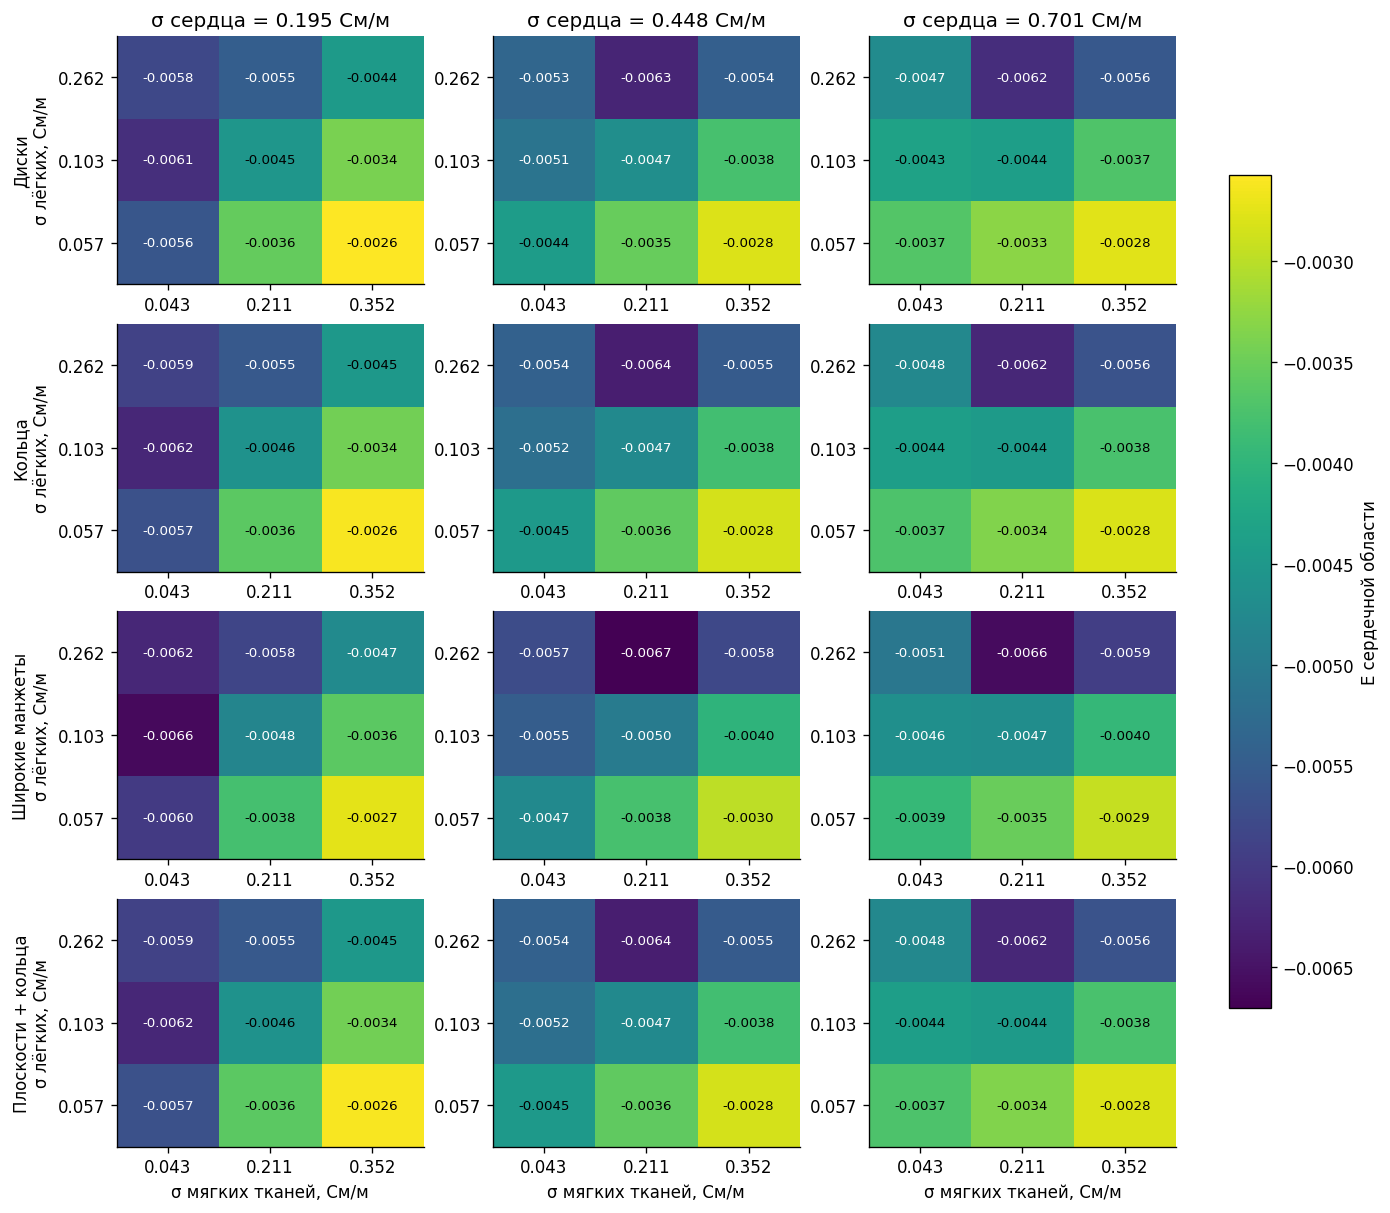

In [13]:
grid=df[(df.inner_mm==20)&(df.outer_mm==80)]
vmin=grid.elasticity_heart.min();vmax=grid.elasticity_heart.max()
fig,axes=plt.subplots(4,3,figsize=(11.5,10),constrained_layout=True)
for i,kind in enumerate(study['montage_kinds']):
    for j,heart_sigma in enumerate(study['heart_levels']):
        ax=axes[i,j]
        g=grid[(grid.electrode_kind==kind)&np.isclose(grid.sigma_heart,heart_sigma)]
        values=g.pivot(index='sigma_lung',columns='sigma_soft',values='elasticity_heart').sort_index().sort_index(axis=1)
        assert values.shape==(3,3) and values.notna().all().all()
        im=ax.imshow(values.to_numpy(),origin='lower',cmap='viridis',vmin=vmin,vmax=vmax,aspect='auto')
        ax.set_xticks(range(3),[f'{x:.3f}' for x in values.columns]);ax.set_yticks(range(3),[f'{x:.3f}' for x in values.index])
        if i==0:ax.set_title(f'σ сердца = {heart_sigma:.3f} См/м')
        if j==0:ax.set_ylabel(short[kind]+'\nσ лёгких, См/м')
        if i==3:ax.set_xlabel('σ мягких тканей, См/м')
        for y in range(3):
            for x in range(3):
                val=values.iloc[y,x]
                ax.text(x,y,f'{val:.4f}',ha='center',va='center',fontsize=8,color='white' if val<(vmin+vmax)/2 else 'black')
fig.colorbar(im,ax=axes,label='E сердечной области',shrink=.75)
plt.show()

**Рисунок 6.** Относительная чувствительность сердечной области при совместном изменении трёх проводимостей. Для всех панелей использована единая цветовая шкала. На осях указаны значения проводимости, См/м; ячейки соответствуют отдельным прямым решениям. Остальные сочетания расстояний включены в полную таблицу и сводки по всем монтажам.

Изменение сердечного коэффициента при варьировании мягкотканного или лёгочного параметра означает, что коэффициент передачи от сердечной области зависит от электрического состояния окружающей среды. Это следствие решения неоднородной объёмной задачи. Поэтому перенос одного коэффициента сердечной чувствительности между существенно различными тканевыми состояниями должен сопровождаться проверкой его устойчивости.

На таком рисунке одновременно изменяются абсолютная производная, исходная сердечная проводимость и базовый импеданс, входящие в определение относительного коэффициента. Физическая интерпретация изменения цвета требует обращения к размерным производным и откликам. Выражение «сердечная чувствительность увеличилась» без указания выбранной величины в дальнейшем следует считать недостаточно определённым.

## 15. Условное сравнение направленности чувствительности

Для описания относительного предпочтения сердечной области введён диагностический показатель

$$Q_h=\frac{|E_h|}{|E_s|+|E_h|+|E_l|},$$

где $Q_h$ — отношение модуля сердечной относительной чувствительности к сумме модулей трёх относительных чувствительностей; индексы $s,h,l$ обозначают мягкотканный, сердечный и лёгочный компартменты. Все коэффициенты берутся в одном состоянии и для одного монтажа.

При ненулевом импедансе общий множитель его нормировки сокращается, поэтому этот показатель эквивалентен отношению модулей размерных откликов на равные процентные возмущения трёх проводимостей. Кость в знаменатель не включена, поскольку она не варьировалась. Показатель характеризует только выбранные три направления возмущения, не учитывает их реальные амплитуды и не является долей сердечного сигнала в измерении.

Для каждого монтажа ниже показаны минимум, медиана и максимум по 27 заданным состояниям. Минимум используется как описательная характеристика наименее благоприятного узла выбранной сетки. Он не гарантирует нижнюю границу между узлами и не имеет вероятностной интерпретации. Введение этого показателя в отчёт не устанавливает его как окончательный критерий оптимизации будущих сборок.

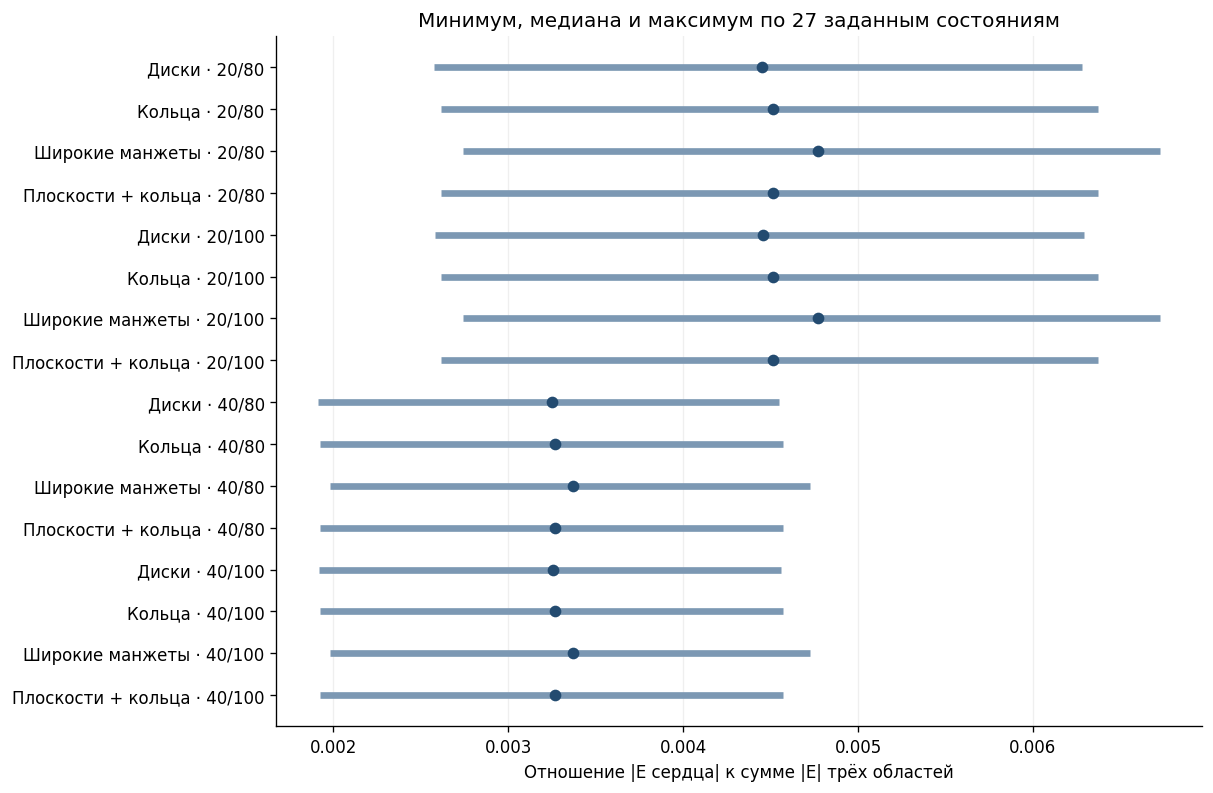

Это отношение сравнивает три **равных относительных возмущения** проводимости. Оно не учитывает различные физиологические амплитуды тканей, шум или изменение геометрии и не является долей сердечного сигнала. Медиана относится к выбранной сетке, не к популяции.

In [14]:
# Selectivity is a diagnostic ratio of derivative magnitudes, not a tissue
# fraction in Z or a probability of identifying the source.
es=df[[f'elasticity_{t}' for t in tissues]].abs()
df['heart_selectivity_equal_fraction']=es.elasticity_heart/es.sum(axis=1)
robust=df.groupby(['montage_index','montage','electrode_kind'],as_index=False).agg(
    heart_min=('heart_selectivity_equal_fraction','min'),heart_median=('heart_selectivity_equal_fraction','median'),heart_max=('heart_selectivity_equal_fraction','max'),
    heart_elasticity_min=('elasticity_heart','min'),heart_elasticity_max=('elasticity_heart','max'),Z_min=('Z_direct_ohm','min'),Z_max=('Z_direct_ohm','max'))
robust=robust.sort_values('montage_index')
fig,ax=plt.subplots(figsize=(10,6.5),constrained_layout=True)
y=np.arange(len(robust))
ax.hlines(y,robust.heart_min,robust.heart_max,color='#7c98b3',lw=4)
ax.scatter(robust.heart_median,y,c='#234b70',zorder=3)
ax.set_yticks(y,base.label);ax.invert_yaxis();ax.grid(axis='x',alpha=.2)
ax.set_xlabel('Отношение |E сердца| к сумме |E| трёх областей');ax.set_title('Минимум, медиана и максимум по 27 заданным состояниям')
plt.show()
display(Markdown('Это отношение сравнивает три **равных относительных возмущения** проводимости. Оно не учитывает различные физиологические амплитуды тканей, шум или изменение геометрии и не является долей сердечного сигнала. Медиана относится к выбранной сетке, не к популяции.'))

**Рисунок 7.** Изменение диагностического отношения сердечной чувствительности по сетке состояний. Отрезок показывает минимум и максимум, точка — медиану. Положения с внутренними электродами ближе к туловищу имеют более высокие значения этого отношения в рассматриваемой модели. Однако окончательный выбор сборки требует иной постановки, если целью является выделение лёгочного, поверхностного или геометрического параметра.

Широкие манжеты дают формально наибольшие значения выбранного отношения и относительной сердечной чувствительности в опорной точке. Различие двух разносов наружной пары для них очень мало. При почти неизменном абсолютном сердечном отклике такой результат не обосновывает заявление о заметном усилении сердечного сигнала или об оптимальности единственного расстояния для реального измерения.

## 16. Локальная разделимость трёх проводимостей

Одна четырёхэлектродная сборка в рассматриваемой действительной постановке даёт одно число — передаточный импеданс. Одного числа недостаточно для независимой локальной оценки трёх неизвестных проводимостей без дополнительных ограничений. Несколько сборок могут увеличить объём информации только в том случае, если их зависимости от параметров достаточно различаются.

Для набора монтажей в общей опорной точке строится матрица производных и её вариант для относительных возмущений:

$$J_{mt}=\left.\frac{\partial Z_m}{\partial\sigma_t}\right|_{\boldsymbol\sigma_0},\qquad
\widetilde J=J\,\mathrm{diag}(\boldsymbol\sigma_0),\qquad
\Delta\mathbf Z\simeq\widetilde J\boldsymbol\eta,$$

где $m$ — номер монтажа; $t$ — номер компартмента; $\mathbf Z$ — вектор импедансов всех монтажей; $\boldsymbol\eta$ — вектор малых относительных изменений проводимостей; $J$ имеет единицы Ом/(См/м), а $\widetilde J$ — Ом. Использование общей опорной точки является модельным условием. При последовательных измерениях на человеке дополнительно потребуются обоснование сопоставимости состояний и учёт ошибок повторной установки.

Сингулярное разложение масштабированной матрицы записывается как

$$\widetilde J=U\,\mathrm{diag}(s_1,s_2,s_3)V^{\mathsf T},\qquad
\kappa_2=\frac{s_1}{s_3},$$

где $U$ и $V$ содержат левые и правые сингулярные векторы; $s_1\ge s_2\ge s_3\ge0$ — сингулярные значения, Ом; $\kappa_2$ — число обусловленности при ненулевом $s_3$. Правые сингулярные векторы задают сочетания относительных изменений проводимостей, а соответствующие сингулярные значения — масштаб отклика набора монтажей на эти сочетания.

Большое число обусловленности означает существенно различающуюся чувствительность к разным сочетаниям параметров. Ненулевой численный ранг не обеспечивает устойчивой обратной оценки при конечной погрешности. При этом величина числа обусловленности зависит от масштабирования параметров и измерений; её нельзя сравнивать между исследованиями без описания этих масштабов.

In [15]:
J=base[[f'dZ_dsigma_{t}' for t in tissues]].to_numpy()*baseline
singular=np.linalg.svd(J,compute_uv=False)
display(pd.DataFrame({'Сингулярное значение':singular,'Единицы':['Ом']*3}))
condition=singular[0]/singular[-1]
display(Markdown(f'Число обусловленности матрицы всех 16 монтажей: **{condition:.3g}**. Большое отношение крайних сингулярных значений указывает на плохую локальную обусловленность: некоторые сочетанные изменения трёх проводимостей меняют набор импедансов гораздо слабее, чем другие. Поэтому наличие 16 монтажей само по себе не гарантирует устойчивое разделение трёх параметров. Вывод относится к опорной точке и принятому масштабированию; практическую идентифицируемость без модели погрешности он не устанавливает.'))

,Сингулярное значение,Единицы
0,867.082593,Ом
1,4.530569,Ом
2,0.001560,Ом


Число обусловленности матрицы всех 16 монтажей: **5.56e+05**. Большое отношение крайних сингулярных значений указывает на плохую локальную обусловленность: некоторые сочетанные изменения трёх проводимостей меняют набор импедансов гораздо слабее, чем другие. Поэтому наличие 16 монтажей само по себе не гарантирует устойчивое разделение трёх параметров. Вывод относится к опорной точке и принятому масштабированию; практическую идентифицируемость без модели погрешности он не устанавливает.

In [16]:
left,singular,Vt=np.linalg.svd(J,full_matrices=False)
weak=Vt[-1].copy()
weak*=np.sign(weak[np.argmax(np.abs(weak))])
weak/=np.max(np.abs(weak))
display(pd.DataFrame({'Компартмент':tissue_labels,'Компонента слабо различимого сочетания относительных изменений':weak}).round(6))
cosines=(J.T@J)/np.outer(np.linalg.norm(J,axis=0),np.linalg.norm(J,axis=0))
with pd.option_context('display.precision',12):
    display(pd.DataFrame(cosines,index=tissue_labels,columns=tissue_labels))
condition_rows=[]
for case,g in df.groupby('case_index'):
    g=g.sort_values('montage_index')
    matrix=g[[f'dZ_dsigma_{t}' for t in tissues]].to_numpy()*g[[f'sigma_{t}' for t in tissues]].to_numpy()
    s=np.linalg.svd(matrix,compute_uv=False)
    condition_rows.append({'case_index':case,'largest_singular_ohm':s[0],'smallest_singular_ohm':s[-1],'condition_number':s[0]/s[-1]})
conditions=pd.DataFrame(condition_rows)
conditions.to_csv(ANALYSIS/'local_conditioning_by_tissue_state.csv',index=False)
pd.DataFrame(Vt,columns=tissues).to_csv(ANALYSIS/'baseline_right_singular_vectors.csv',index=False)
display(Markdown(f'При повторении этого локального анализа в каждом из 27 тканевых состояний число обусловленности находится в пределах **{conditions.condition_number.min():.3g}–{conditions.condition_number.max():.3g}**. В каждой точке использованы её собственные проводимости для масштабирования; это набор локальных характеристик, не доказательство глобальной единственности обратного решения.'))

,Компартмент,Компонента слабо различимого сочетания относительных изменений
0,Мягкотканный фон,-0.000002
1,Сердечная область,1.000000
2,Лёгкие,-0.096931


,Мягкотканный фон,Сердечная область,Лёгкие
Мягкотканный фон,1.000000000000,0.987073966784,0.987053739374
Сердечная область,0.987073966784,1.000000000000,0.999999826881
Лёгкие,0.987053739374,0.999999826881,1.000000000000


При повторении этого локального анализа в каждом из 27 тканевых состояний число обусловленности находится в пределах **1.19e+05–1.18e+06**. В каждой точке использованы её собственные проводимости для масштабирования; это набор локальных характеристик, не доказательство глобальной единственности обратного решения.

Первая дополнительная таблица показывает правый сингулярный вектор, соответствующий наименьшему сингулярному значению, нормированный так, чтобы наибольшая по модулю компонента равнялась единице. Общий знак вектора произволен. Его компоненты описывают направление малых совместных относительных изменений; единица здесь не означает физического изменения проводимости на 100%. Для проверки такого направления конечным возмущением потребовался бы отдельно выбранный малый множитель.

Наиболее слабо различимое направление в опорной точке преимущественно связывает изменения сердечной и лёгочной проводимостей противоположных знаков. Это модельное направление компенсации откликов, а не установленная взаимосвязь физиологических процессов.

Вторая таблица содержит косинусы углов между столбцами масштабированной матрицы. Значение, близкое по модулю к единице, означает похожую структуру откликов на изменения двух параметров по набору монтажей. Эта мера характеризует сходство направлений столбцов, а не статистическую корреляцию физиологических процессов.

Результат показывает, что увеличение числа близких по геометрии сборок не обязательно обеспечивает качественно новую информацию. При разработке существенно иных сборок следует проверять одновременно величину целевого отклика и различие направлений чувствительности. Для оценки практической разрешающей способности потребуются допустимые ошибки параметров и измерений; в этой серии они не заданы, поэтому доверительные интервалы обратной оценки не вычисляются.

## 17. Результаты проверки предположений

| Исследовательский вопрос | Результат настоящего расчёта | Граница интерпретации |
|---|---|---|
| Меняет ли форма контакта абсолютную сердечную чувствительность? | В опорной точке различия между 16 монтажами малы по сравнению с самим сердечным откликом | Вывод относится к данной геометрии, полярности и параметру цельной сердечной области |
| Усиливает ли смещение внутренней пары от 20 к 40 мм сердечный отклик? | Базовый импеданс и мягкотканный отклик меняются заметно; выраженного усиления сердечного отклика не обнаружено | Одновременно смещалась наружная пара; независимый эффект только измерительных электродов не выделен |
| Получено ли преимущество наружных плоскостей перед узкими манжетами? | В 108 совпадающих состояниях результаты близки | Сравниваются две конкретные контактные дискретизации; физическая эквивалентность не установлена |
| Можно ли использовать один набор производных во всём диапазоне? | Чувствительности зависят от тканевого состояния; экстраполяция опорной линейной модели даёт значительное расхождение | Для конечного физиологического возмущения нужен его собственный масштаб и отдельная проверка линейности |
| Можно ли устойчиво оценить три проводимости по этим 16 монтажам? | Локальная матрица плохо обусловлена; близкие монтажи дают во многом сходную информацию | Без погрешностей измерения практическая точность и допустимость обратного решения не определены |
| Работоспособна ли реализация прямого и производного расчёта? | Пройдены проверки полноты, матриц, взаимности, невязки, конечных разностей и одного независимого решения | Подтверждена численная согласованность фиксированной дискретной задачи |

Таким образом, основное достижение этапа состоит в формировании проверяемой процедуры расчёта и интерпретации чувствительности. Ограниченная информативность рассмотренных монтажей и зависимость коэффициентов от фоновых тканей являются содержательными результатами проверки предположений. Они определяют требования к следующему вычислительному эксперименту, но не завершают разработку или валидацию методики оценки функций сердца.

## 18. Источники неопределённости и ограничения переноса

**Геометрия и анатомия.** Исследуется одна индивидуальная КТ на вдохе. Искусственные цилиндры не воспроизводят реальную структуру рук, а модельные плоскости соединения не подтверждены как экспериментальные анатомические ориентиры. Геометрическое разложение фоновой производной показало существенный вклад участков дистальнее соединения; это требует осторожности при переносе выводов на реальные руки и тем более на грудные сборки. Не исследованы изменение положения тела, кривизны поверхности, толщины подкожных слоёв и формы органов.

**Сегментация и назначение тканей.** Классы элементов получены из ручных масок по центроидам тетраэдров. Неопределённость границ, пересечения масок и зависимость объёмов классов от сетки не выражены в виде доверительных интервалов. Объём сердечной области не разделён на кровь и миокард; лёгкие изменяются совместно одним параметром. Такая параметризация ограничивает как прямую чувствительность, так и смысл возможной обратной оценки.

**Электрические свойства.** Проводимости скалярны и действительны. Не учтены анизотропия мышц и миокарда, отдельная кожа и диэлектрическая составляющая. Тканевые ориентиры и прежние параметры проекта имеют разные источники. Объединение их в одну сетку является явно заданным планом исследования устойчивости модели, а не доказательством физиологической реализуемости всех сочетаний.

**Дыхательные и сердечные изменения.** Варьируется только проводимость при постоянной геометрии. Вентиляционное изменение объёма лёгких, перемещение сердца, изменение формы камер и сосудистая динамика не рассчитывались. Поэтому производные этой серии не описывают весь отклик между вдохом и выдохом или за сердечный цикл. Сопоставление с такими сигналами потребует разделения электрических и геометрических механизмов.

**Контакты и аппаратная схема.** Удельный контактный импеданс фиксирован. Не варьировались площадь реального прилегания, ручная установка, ориентация, контактные слои, входное сопротивление измерителя и межканальное влияние. Последнее может быть существенным для конкретного прибора, однако его механизм не включён в данную модель. Сходство результатов двух идеализированных контактов не устанавливает их эквивалентность при экспериментальной регистрации.

**Сетка и алгоритмы.** Пройдены численные проверки на одной сетке, но сеточная сходимость интегральных чувствительностей и контактных поверхностей внутри цилиндров не исследована. Малая невязка контролирует решение дискретной системы, а не различие дискретной и непрерывной задач. Одно независимое решение и 24 конечно-разностных сопоставления не обеспечивают одинаковую глубину проверки всех возможных будущих параметров и монтажей.

**План параметрического исследования.** Три уровня каждого параметра образуют широкий, но редкий набор сценариев. Непроверенные состояния между узлами могут содержать дополнительные особенности. Минимумы, максимумы и медианы в отчёте относятся к перечисленным узлам. Нельзя считать их вероятностными границами, независимыми от выбора сетки.

**Измерительная неопределённость и обратная задача.** Отдельно остаются ошибки измерения напряжения и тока, воспроизводимость установки, изменение состояния между измерениями и расхождение модели с анатомией. Для них не вводилось одно общее распределение или произвольный уровень шума. Поэтому не вычислены обнаружимость малого физиологического изменения, точность восстановления проводимостей и достоверность оценки функций сердца.

## 19. Общая постановка для других электродных сборок

### 19.1. Объект дальнейшего сравнения

При переходе к новым сборкам следует сохранить общий принцип: каждая строка результата должна однозначно связывать анатомическую модель, компартменты, параметры состояния, все физически присутствующие контакты, токовую пару, измерительную пару и определение чувствительности. Геометрическое название сборки само по себе не определяет измерительную задачу.

Будущий набор параметров может включать проводимости нескольких тканевых областей, удельные сопротивления, характеристики анизотропии, контактные импедансы, толщины слоёв, координаты границ и объёмы органов. Сначала необходимо определить физический смысл каждого параметра и способ его изменения. Совместное включение параметров, описывающих одно и то же изменение разными способами, может создать искусственную избыточность обратной задачи.

Для каждой новой сборки должны быть заданы допустимые поверхности установки и анатомические ориентиры, фактическая форма и площадь контакта, его роль в возбуждении и измерении, полярность, частота и токовая нормировка. Если на теле одновременно находятся дополнительные проводящие электроды, они могут входить в полную электродную модель даже при нулевом суммарном токе. Электрическое подключение нескольких каналов и контактов требуется описывать согласно конкретному прибору; последовательность независимых расчётов четырёх электродов не заменяет такую схему автоматически.

### 19.2. Масштаб сравниваемых возмущений

Для каждого параметра необходимо выбрать физически обоснованный масштаб малого изменения. Проводимости можно сравнивать при одинаковом процентном возмущении, если вопрос сформулирован именно таким образом. Для толщины или координаты естественнее задать изменение в миллиметрах; для объёма — в миллилитрах. Нельзя сравнивать размерные производные разных типов параметров только по их численному модулю.

Для общего набора параметров применяется масштабированная матрица

$$J^{(p)}_{mj}=\frac{\partial Z_m}{\partial p_j},\qquad
J^{(*)}=J^{(p)}\,\mathrm{diag}(a_1,\ldots,a_P),$$

где $p_j$ — параметр с собственными физическими единицами; $P$ — число параметров; $a_j$ — заранее выбранный масштаб его изменения в тех же единицах; $m$ — номер измерения; $J^{(*)}$ имеет единицы Ом. Масштабы $a_j$ следует связывать с исследовательским вопросом, протоколом или обоснованным сценарием неопределённости. Их выбор фиксируется до интерпретации ранжирования.

Если передаточный импеданс близок к нулю, относительная чувствительность с делением на $Z$ становится неустойчивой как критерий сравнения. Малое базовое значение может дать большой относительный коэффициент при малом абсолютном сигнале. В такой ситуации необходимы размерный отклик, модель измерения и явно заданный масштаб нормировки. Перестановка измерительных полюсов также меняет знаки $Z$ и размерных производных; полярность должна сохраняться при попарном сравнении.

### 19.3. Критерии в зависимости от научной задачи

| Цель применения сборки | Основные характеристики | Дополнительные сведения для интерпретации |
|---|---|---|
| Регистрация изменения одного выбранного компартмента | Размерный отклик на обоснованное возмущение целевого параметра | Отклики мешающих параметров и измерительная погрешность |
| Оценка мягкотканной поправки | Чувствительность к поверхностным областям и зависимость от глубинных тканей | Толщина и кривизна слоёв, контакт и индивидуальная анатомия |
| Разделение нескольких проводимостей | Масштабированная матрица производных, её сингулярные значения и сходство столбцов | Сопоставимость состояний между измерениями, ошибка модели |
| Оценка изменения объёма или положения органа | Производная по конкретному геометрическому параметру | Правило деформации, связь с КТ и физиологическим движением |
| Выбор набора из нескольких сборок | Совместная информативность и устойчивость к мешающим параметрам | Число доступных каналов, физическое подключение и протокол |
| Перенос коэффициентов между состояниями | Изменение производных по диапазону фоновых параметров | Проверка линейности, границы применимости и независимые данные |

Универсального «лучшего» монтажа без выбранной задачи нет. Сборка с большим целевым откликом может одновременно иметь большой отклик на мешающий параметр; набор сборок с малыми, но различающимися откликами может оказаться полезнее для разделения источников. В обоих случаях необходим количественный анализ в единых условиях.

### 19.4. Неопределённость и обнаружимость

Если в дальнейшем будет установлена ковариационная матрица измерительных ошибок, анализ можно дополнить их масштабированием:

$$J_w=WJ^{(*)},\qquad W\Sigma_ZW^{\mathsf T}=I,$$

где $\Sigma_Z$ — положительно определённая ковариационная матрица ошибок измерения импедансов, Ом²; $W$ — матрица преобразования к единичной ковариации; $I$ — единичная матрица; $J_w$ — матрица чувствительности, нормированная на масштабы параметров и измерительных ошибок. Такое преобразование требует обоснованной ковариации; оно само по себе не устанавливает гауссовость ошибок. При известных только детерминированных границах следует применять соответствующий анализ ограниченных возмущений, не заменяя эти границы произвольным вероятностным шумом.

Помимо измерительных ошибок необходимо учитывать контакт, установку электродов, тканевую параметризацию и геометрию. Их удобно рассматривать как отдельные мешающие параметры, когда определён способ их возмущения. Обнаружимость, точность оценки и устойчивость к модельному расхождению затем оцениваются раздельно. Наличие большой производной или малого числа обусловленности одного номинального расчёта не завершает эту проверку.

## 20. Последовательность исследования новой сборки

1. **Определить измеряемую величину и целевой параметр.** Указать, требуется ли регистрация изменения проводимости, разделение тканевых вкладов, оценка толщины, смещения или объёма. Зафиксировать допустимую ошибку результата, если она уже обоснована.
2. **Описать анатомию и компартменты.** Установить происхождение геометрии, состояние дыхания, правила назначения областей, приоритет масок и фиксированные параметры. Проверить полноту разбиения и влияние принятой параметризации.
3. **Задать контакты и электрическое подключение.** Сохранить поверхности, координаты, площади, полярность, токовые и измерительные пары, контактные параметры и все одновременно присутствующие электроды.
4. **Проверить новую прямую задачу.** Повторить геометрический контроль, оценку качества сетки, невязку и взаимность. Для новой формы контакта проверить сборку контактной матрицы и её дискретизацию.
5. **Задать опорные состояния и план возмущений.** Разделить малые изменения для проверки производной, широкий диапазон параметрической устойчивости и предполагаемые реальные физиологические изменения. Эти три масштаба могут различаться.
6. **Рассчитать прямые и взаимные поля.** Для проводимостных параметров использовать объёмные матрицы соответствующих областей. Для контакта, геометрии и состава ткани определить собственную производную или согласованные конечные изменения.
7. **Проверить производные.** Использовать несколько шагов, анализировать ошибку усечения и численную погрешность, включать трудные состояния и новые типы параметров. Почти нулевая производная требует абсолютного критерия наряду с относительным.
8. **Сравнить сборки при одинаковых состояниях.** Представить размерные и масштабированные чувствительности, влияние мешающих параметров и пространственные карты, если они нужны для анатомической интерпретации.
9. **Исследовать устойчивость по состояниям и погрешностям.** Проверить нелинейность, взаимодействия параметров, сеточную сходимость, контакт, повторную установку и неопределённость анатомии. Для набора сборок исследовать совместную матрицу чувствительности.
10. **Связать расчёт с независимыми данными.** Сопоставить предсказанные изменения с измерением или иной референсной моделью и только после этого устанавливать экспериментальную точность и допустимость сокращения входных данных.

Текущая серия выполняет часть этой последовательности для одного ограниченного семейства монтажей. Она предоставляет проверенные определения, пример параметрической матрицы, алгоритм производных и набор диагностик. Пространственные карты, геометрические производные, полная модель погрешности и экспериментальная валидация остаются задачами следующего этапа.

Программный профиль текущей серии специализирован под четыре электрода, три изменяемые проводимости и фиксированный перечень монтажей на руках. Методические формулы имеют более общую область применения, однако наличие этих формул не означает, что произвольная сборка уже поддерживается программой. Для новых конфигураций потребуется явно изменить геометрическую спецификацию, список измерений и план параметров с повторным контролем соответствующих частей реализации.

## 21. Воспроизводимость расчёта и структура результатов

Следует различать повторное выполнение отчёта и повторное решение FEM-задачи. Ноутбук читает сохранённые прямые решения, проверяет их происхождение и формирует вторичные сводки. Его повторное выполнение обновляет таблицы, графики и анализ линейности без запуска всей численной серии. Полное воспроизведение требует исходной сетки, тканевых поверхностей, использованной конфигурации и зафиксированной версии расчётных функций.

В MATLAB выполняются подготовка модели, назначение тканей, построение электродов, сборка объёмных матриц и сопоставление контактной сборки с EIDORS. Python решает полные разреженные системы для заданных проводимостей, вычисляет взаимные производные и сохраняет контрольные показатели. Такое распределение функций не меняет математическую постановку. Исходники, реально использованные при получении результатов, сохранены отдельно; последующее изменение рабочей копии не должно незаметно менять происхождение старой серии.

| Группа данных | Содержание | Назначение |
|---|---|---|
| Паспорт расчёта | Состав входов, уровни параметров, контрольные суммы и версии | Прослеживаемость исходного численного эксперимента |
| Геометрия контактов | Площади, координаты, роли, число граней и результаты контроля | Проверка фактической реализации каждого монтажа |
| Основная матрица | Проводимости, прямой и взаимный импедансы, производные, относительные коэффициенты | Вычислительный первоисточник сравнения |
| Контроль производных | Шаги, конечно-разностные оценки и расхождения | Проверка взаимной формулы |
| Независимое решение | Результаты второго алгоритма на той же сетке | Межалгоритмическая проверка |
| Вторичный анализ | Сводки компартментов, геометрические разности, линейность, взаимодействия и обусловленность | Производные таблицы настоящей редакции |

В основной таблице расстояние до внутренней пары и разнос I–V хранятся раздельно. Проводимости имеют единицы См/м; импедансы — Ом; производные — Ом/(См/м); относительные чувствительности безразмерны. Номер состояния служит ключом к сочетанию параметров и не имеет временного смысла. Время выполнения относится к производительности вычисления и не является физиологической длительностью.

Для технического воспроизведения предусмотрены [описание расчётных профилей](../MATLAB_TRKG4_real_subjects/docs/PIPELINE_FOR_NOTEBOOKS.md), [MATLAB-профиль исследования](../MATLAB_TRKG4_real_subjects/src/run_trkg4_arm_conductivity_matrix.m), [план проводимостей](../MATLAB_TRKG4_real_subjects/src/trkg4_arm_conductivity_design.m), [решатель матрицы](../MATLAB_TRKG4_real_subjects/tools/solve_arm_conductivity_matrix.py) и [генератор отчёта](../MATLAB_TRKG4_real_subjects/tools/build_arm_conductivity_notebook.py). Точка входа MATLAB — профиль `arm_conductivity_matrix` функции `run_pipeline`; техническая команда приведена в документации. При изменении расчётного кода новая серия должна сохраняться в отдельном выходном каталоге. Продолжение старого расчёта несовпадающей версией исходников блокируется проверкой контрольных сумм.

Исходная геометрия и медицинские материалы доступны в локальной исследовательской среде и не входят автоматически в Git. Это ограничение переносимого воспроизведения фиксируется отдельно от доказательности численных результатов. Для повторного чтения этого отчёта необходимо сохранить комплект результатов; для новой прямой серии требуется дополнительно доступ к разрешённым исходным данным и зависимостям MATLAB/EIDORS и Python.

## 22. Полная численная матрица

[Основная таблица результатов в CSV](../MATLAB_TRKG4_real_subjects/output/exploratory/arm_sigma_20260908/matrix_results.csv) содержит все исходные размерные производные и численный контроль. Ниже продублированы проводимости, импеданс и относительные чувствительности всех 432 состояний. Читательская таблица округлена для отображения; расчётные сводки используют исходную точность сохранённых чисел.

In [17]:
cols=['montage_index','electrode_kind','inner_mm','outer_mm','case_index','sigma_soft','sigma_heart','sigma_lung','Z_direct_ohm','elasticity_soft','elasticity_heart','elasticity_lung']
full=df.sort_values(['montage_index','case_index'])[cols].copy()
full.electrode_kind=full.electrode_kind.map(short)
full.columns=['Монтаж','Контакт','Внутр., мм','Разнос, мм','Состояние','σ фон','σ сердце','σ лёгкие','Z, Ом','E фон','E сердце','E лёгкие']
display(HTML('<details><summary>Все 432 состояния: проводимости, импеданс и относительные чувствительности</summary>'+full.to_html(index=False,float_format=lambda x:f'{x:.6g}',border=0)+'</details>'))

Монтаж,Контакт,"Внутр., мм","Разнос, мм",Состояние,σ фон,σ сердце,σ лёгкие,"Z, Ом",E фон,E сердце,E лёгкие
1,Диски,20,80,1,0.0432739,0.195435,0.0574491,860.534,-0.938526,-0.00559909,-0.0503571
1,Диски,20,80,2,0.211498,0.195435,0.0574491,191.993,-0.957689,-0.00355261,-0.0366773
1,Диски,20,80,3,0.351828,0.195435,0.0574491,117.632,-0.967456,-0.00257112,-0.0285318
1,Диски,20,80,4,0.0432739,0.448118,0.0574491,856.931,-0.938778,-0.00442146,-0.0515558
1,Диски,20,80,5,0.211498,0.448118,0.0574491,191.422,-0.956267,-0.00353073,-0.0381698
1,Диски,20,80,6,0.351828,0.448118,0.0574491,117.368,-0.966059,-0.00279481,-0.0297257
1,Диски,20,80,7,0.0432739,0.700801,0.0574491,855.382,-0.939028,-0.00367087,-0.052164
1,Диски,20,80,8,0.211498,0.700801,0.0574491,191.129,-0.95575,-0.00329722,-0.038943
1,Диски,20,80,9,0.351828,0.700801,0.0574491,117.222,-0.965472,-0.00275813,-0.0303598
1,Диски,20,80,10,0.0432739,0.195435,0.102656,836.508,-0.942491,-0.00614598,-0.0465213


## 23. Методические выводы и дальнейший этап

Выполненная работа сформировала воспроизводимый пример оценки чувствительности передаточного импеданса к трём эффективным проводимостям. Исправлена роль плоскостных контактов, задана полная матрица состояний, реализована взаимная формула производных и проверена её численная согласованность. Эти результаты относятся к настройке и верификации расчётного подхода на фиксированной геометрии.

Для исследованных монтажей форма и положение контактов существенно влияют на базовый импеданс и мягкотканный отклик. Абсолютный сердечный отклик при одинаковом исходном состоянии меняется значительно слабее. Замена наружных узких манжет поперечными токовыми поверхностями сечений не дала выраженного преимущества по этому отклику в рассмотренной модели. Условное преимущество широких манжет по относительным показателям требует интерпретации совместно с базовым импедансом и не устанавливает оптимальную сборку.

Проводимости окружающих компартментов изменяют чувствительность сердечной области, поэтому один коэффициент не может без проверки переноситься на широкий диапазон состояний. Матрица откликов похожих монтажей плохо обусловлена для совместной оценки трёх проводимостей. Следующий этап должен исследовать сборки с существенно различающимися прямыми и взаимными полями и проверять, дают ли они новую информацию о целевых и мешающих параметрах.

Для дальнейшей работы предлагается сохранить раздельное представление трёх результатов: размерного отклика на обоснованное возмущение, устойчивости этого отклика к состоянию остальных компартментов и совместной разделимости параметров по нескольким измерениям. Физическую и экспериментальную проверку следует выполнять относительно конкретной анатомии, прибора и протокола. До завершения этих проверок расчётные коэффициенты остаются инструментом разработки методики, а не валидированной оценкой функций сердца.

## 24. Источники и их роль

1. **IT’IS Foundation. Tissue Properties Database, V5.0.** DOI: [10.13099/VIP21000-05-0](https://doi.org/10.13099/VIP21000-05-0). [Описание диэлектрических свойств](https://itis.swiss/virtual-population/tissue-properties/database/dielectric-properties). Использовано для частотных ориентиров проводимости тканей; индивидуальная применимость принята как ограниченное модельное допущение.
2. **Kangasmaa O., Laakso I., Schmid G.** Estimating Human Fat and Muscle Conductivity From 100 Hz to 1 MHz Using Measurements and Modelling. *Bioelectromagnetics*, 2025, 46, e22541. DOI: [10.1002/bem.22541](https://doi.org/10.1002/bem.22541). Использовано для обсуждения анизотропии и неопределённости переноса тканевых ориентиров; индивидуальные параметры Nix из этой работы не выводились.
3. **Gabriel C., Peyman A., Grant E. H.** Electrical conductivity of tissue at frequencies below 1 MHz. *Physics in Medicine & Biology*, 2009, 54, 4863–4878. DOI: [10.1088/0031-9155/54/16/002](https://doi.org/10.1088/0031-9155/54/16/002). Использовано для характеристики происхождения и границ переноса низкочастотных тканевых данных.
4. **Somersalo E., Cheney M., Isaacson D.** Existence and Uniqueness for Electrode Models for Electric Current Computed Tomography. *SIAM Journal on Applied Mathematics*, 1992, 52(4), 1023–1040. DOI: [10.1137/0152060](https://doi.org/10.1137/0152060). Теоретический контекст полной электродной модели; результаты этой публикации не заявляются как валидация поперечных токовых поверхностей настоящей серии.
5. **EIDORS. Документация функции формирования матрицы полей и контактных интегралов.** [Описание и исходный код](https://eidors3d.sourceforge.net/doc/eidors/solvers/forward/system_mat_fields.html). Использовано для проверки структуры дискретной контактной модели и единиц удельного контактного импеданса. Точная использованная локальная версия указана в паспорте результатов.

Литературные сведения обосновывают определения и выбранные ориентиры. Численные значения импедансов, производных, сравнений и показателей обусловленности в настоящем отчёте являются результатами собственного вычислительного эксперимента. Исторические опорные параметры и решения автора обозначены отдельно от внешних литературных данных.